# Plasma-column simulation analysis plots

This notebook analyzes plasma-column simulation outputs from three methods:

1. **Seeded neutralization model**
2. **Python callback proton-impact source**
3. **C++ `ion_impact_ionization` BackgroundMCC source**

Main global diagnostics:

\begin{equation}
f_e(t)=\frac{N_e(t)}{N_p(t)},\qquad
f_i(t)=\frac{N_i(t)}{N_p(t)},\qquad
f_{\rm net}(t)=\frac{N_e(t)-N_i(t)}{N_p(t)} .
\end{equation}

For source-process validation:

\begin{equation}
R_{\rm pair}=\frac{\Delta N_e}{\Delta N_i}\approx 1,
\end{equation}

because each proton-impact ionization event should create one electron and one gas ion:

\begin{equation}
p+\mathrm{gas}\rightarrow p+\mathrm{gas}^{+}+e^- .
\end{equation}

The optional plotfile section can also generate transverse and longitudinal density profiles, similar to the electron-column analysis style used in earlier WARP studies.

In [1]:
from pathlib import Path
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

SIM_ROOT = Path.cwd()
RUNS_DIR = SIM_ROOT / "runs"
PLOTS_DIR = SIM_ROOT / "analysis_plots"
PLOTS_DIR.mkdir(exist_ok=True)

print("SIM_ROOT =", SIM_ROOT)
print("RUNS_DIR =", RUNS_DIR)
print("PLOTS_DIR =", PLOTS_DIR)

SIM_ROOT = /home/cspark/Work/projects/plasma_column/simulations
RUNS_DIR = /home/cspark/Work/projects/plasma_column/simulations/runs
PLOTS_DIR = /home/cspark/Work/projects/plasma_column/simulations/analysis_plots



## 1. Discover simulation cases

Expected files:

| Method | History file |
|---|---|
| Seeded model | `neutralization_from_particle_number.csv` |
| Python callback | `callback_neutralization_from_particle_number.csv` |
| C++ MCC | `cxx_mcc_neutralization_from_particle_number.csv` |
| Raw fallback | `reducedfiles/particle_number.txt` |


In [2]:
def infer_method(case_dir: Path) -> str:
    name = case_dir.name.lower()
    if (case_dir / "cxx_mcc_neutralization_from_particle_number.csv").exists() or name.startswith("cxx_"):
        return "C++ MCC"
    if (case_dir / "callback_neutralization_from_particle_number.csv").exists() or name.startswith("callback"):
        return "Python callback"
    if (case_dir / "neutralization_from_particle_number.csv").exists() or "seeded" in name or "vacuum" in name:
        return "Seeded"
    return "Unknown"


def infer_gas(case_name: str) -> str:
    n = case_name.lower()
    if "kr" in n:
        return "Kr"
    if "h2" in n:
        return "H2"
    if "vacuum" in n:
        return "vacuum"
    return "unknown"


def find_raw_particle_number(case_dir: Path) -> Path | None:
    candidates = [
        case_dir / "reducedfiles" / "particle_number.txt",
        case_dir / "reducedfiles" / "particle_number",
        case_dir / "reducedfilesparticle_number.txt",
        case_dir / "reducedfilesparticle_number",
        case_dir / "particle_number.txt",
        case_dir / "particle_number",
    ]
    for p in candidates:
        if p.exists():
            return p
    matches = sorted([p for p in case_dir.rglob("*particle_number*") if p.is_file()])
    return matches[0] if matches else None


def parse_particle_number_raw(path: Path, output_csv: Path | None = None) -> pd.DataFrame:
    data = np.genfromtxt(path, comments="#", delimiter=",")
    if data.size == 0:
        raise ValueError(f"Empty ParticleNumber file: {path}")
    if data.ndim == 1:
        data = data.reshape(1, -1)

    n_species = 3
    min_cols = 2 + 2 * (1 + n_species)
    if data.shape[1] < min_cols:
        raise ValueError(f"Unexpected ParticleNumber columns in {path}: got {data.shape[1]}, expected >= {min_cols}")

    step = data[:, 0].astype(int)
    time_s = data[:, 1]

    macro_total = data[:, 2]
    macro_beam_p = data[:, 3]
    macro_e = data[:, 4]
    macro_gas_i = data[:, 5]

    phys_offset = 2 + 1 + n_species
    physical_total = data[:, phys_offset]
    physical_beam_p = data[:, phys_offset + 1]
    physical_e = data[:, phys_offset + 2]
    physical_gas_i = data[:, phys_offset + 3]

    valid = physical_beam_p > 0.0
    electron_over_proton = np.full_like(physical_e, np.nan, dtype=float)
    ion_over_proton = np.full_like(physical_gas_i, np.nan, dtype=float)
    global_net_neutralization = np.full_like(physical_e, np.nan, dtype=float)

    np.divide(physical_e, physical_beam_p, out=electron_over_proton, where=valid)
    np.divide(physical_gas_i, physical_beam_p, out=ion_over_proton, where=valid)
    np.divide(physical_e - physical_gas_i, physical_beam_p, out=global_net_neutralization, where=valid)

    df = pd.DataFrame({
        "step": step,
        "time_s": time_s,
        "macro_total": macro_total,
        "macro_beam_protons": macro_beam_p,
        "macro_plasma_electrons": macro_e,
        "macro_gas_ions": macro_gas_i,
        "physical_total": physical_total,
        "physical_beam_protons": physical_beam_p,
        "physical_plasma_electrons": physical_e,
        "physical_gas_ions": physical_gas_i,
        "electron_over_proton": electron_over_proton,
        "ion_over_proton": ion_over_proton,
        "global_net_neutralization": global_net_neutralization,
    })

    if output_csv is not None:
        df.to_csv(output_csv, index=False)

    return df


def load_case_history(case_dir: Path):
    method = infer_method(case_dir)
    gas = infer_gas(case_dir.name)
    meta = {
        "case": case_dir.name,
        "path": str(case_dir),
        "method": method,
        "gas": gas,
        "history_source": None,
        "model_source": None,
    }

    hist = None
    for p in [
        case_dir / "neutralization_from_particle_number.csv",
        case_dir / "callback_neutralization_from_particle_number.csv",
        case_dir / "cxx_mcc_neutralization_from_particle_number.csv",
    ]:
        if p.exists():
            hist = pd.read_csv(p)
            meta["history_source"] = p.name
            break

    if hist is None:
        raw = find_raw_particle_number(case_dir)
        if raw is not None:
            out_csv = case_dir / "analysis_particle_number_history.csv"
            hist = parse_particle_number_raw(raw, output_csv=out_csv)
            meta["history_source"] = f"{raw.relative_to(case_dir)} -> {out_csv.name}"

    model = None
    for p in [case_dir / "neutralization_model.csv", case_dir / "neutralization_source_model.csv"]:
        if p.exists():
            model = pd.read_csv(p)
            meta["model_source"] = p.name
            break

    return hist, model, meta


def discover_cases(runs_dir: Path = RUNS_DIR):
    cases = []
    if not runs_dir.exists():
        print(f"Runs directory does not exist: {runs_dir}")
        return cases

    for case_dir in sorted([p for p in runs_dir.iterdir() if p.is_dir()]):
        hist, model, meta = load_case_history(case_dir)
        if hist is not None:
            cases.append((case_dir, hist, model, meta))
    return cases


cases = discover_cases()
print(f"Discovered {len(cases)} cases:")
for _, _, _, meta in cases:
    print(f"  {meta['case']:38s} | {meta['method']:16s} | {meta['gas']:8s} | {meta['history_source']}")

if not cases:
    print("\nNo histories found. Check RUNS_DIR or run simulations first.")


Discovered 8 cases:
  callback_H2_2k                         | Python callback  | H2       | callback_neutralization_from_particle_number.csv
  callback_Kr_2k                         | Python callback  | Kr       | callback_neutralization_from_particle_number.csv
  callback_vacuum_2k                     | Python callback  | vacuum   | callback_neutralization_from_particle_number.csv
  cxx_H2_mcc_20k_physical                | C++ MCC          | H2       | reducedfiles/particle_number.txt -> analysis_particle_number_history.csv
  cxx_Kr_mcc_20k_physical                | C++ MCC          | Kr       | reducedfiles/particle_number.txt -> analysis_particle_number_history.csv
  h2_seeded_full                         | Seeded           | H2       | neutralization_from_particle_number.csv
  kr_seeded_full                         | Seeded           | Kr       | neutralization_from_particle_number.csv
  vacuum_full                            | Seeded           | vacuum   | reducedfiles/particle_n


## 2. Summary and validation metrics

For a continuously injected beam, $N_p(0)$ can be zero. The notebook therefore computes $\Delta N_e$, $\Delta N_i$, and $\Delta N_p$ from the first diagnostic row with $N_p>0$.


In [3]:
def first_valid_index(df: pd.DataFrame) -> int | None:
    valid = np.asarray(df["physical_beam_protons"] > 0.0)
    if not np.any(valid):
        return None
    return int(np.where(valid)[0][0])


def summarize_case(case_dir: Path, hist: pd.DataFrame, model: pd.DataFrame | None, meta: dict) -> dict:
    i0 = first_valid_index(hist)
    last = hist.iloc[-1]

    result = {
        "case": meta["case"],
        "method": meta["method"],
        "gas": meta["gas"],
        "n_rows": len(hist),
        "first_step": int(hist["step"].iloc[0]),
        "last_step": int(hist["step"].iloc[-1]),
        "final_time_s": float(hist["time_s"].iloc[-1]),
        "history_source": meta["history_source"],
        "model_source": meta["model_source"],
        "final_Np": float(last["physical_beam_protons"]),
        "final_Ne": float(last["physical_plasma_electrons"]),
        "final_Ni": float(last["physical_gas_ions"]),
        "final_Ne_over_Np": float(last["electron_over_proton"]) if "electron_over_proton" in hist else np.nan,
        "final_Ni_over_Np": float(last["ion_over_proton"]) if "ion_over_proton" in hist else np.nan,
        "final_net": float(last["global_net_neutralization"]) if "global_net_neutralization" in hist else np.nan,
    }

    if i0 is None:
        result.update({
            "first_valid_step": np.nan,
            "delta_Np": np.nan,
            "delta_Ne": np.nan,
            "delta_Ni": np.nan,
            "delta_Ne_over_delta_Ni": np.nan,
            "delta_net_over_final_Np": np.nan,
        })
    else:
        ref = hist.iloc[i0]
        dNp = last["physical_beam_protons"] - ref["physical_beam_protons"]
        dNe = last["physical_plasma_electrons"] - ref["physical_plasma_electrons"]
        dNi = last["physical_gas_ions"] - ref["physical_gas_ions"]
        final_Np = last["physical_beam_protons"]

        result.update({
            "first_valid_step": int(ref["step"]),
            "delta_Np": float(dNp),
            "delta_Ne": float(dNe),
            "delta_Ni": float(dNi),
            "delta_Ne_over_delta_Ni": float(dNe / dNi) if dNi != 0 else np.nan,
            "delta_net_over_final_Np": float((dNe - dNi) / final_Np) if final_Np > 0 else np.nan,
        })

    return result


summary = pd.DataFrame([summarize_case(cd, h, m, meta) for cd, h, m, meta in cases])
if len(summary):
    summary = summary.sort_values(["method", "gas", "case"]).reset_index(drop=True)
    display(summary)

    summary_file = PLOTS_DIR / "simulation_case_summary.csv"
    summary.to_csv(summary_file, index=False)
    print("Wrote:", summary_file)

    compact_cols = [
        "case", "method", "gas", "last_step", "final_time_s",
        "final_Np", "final_Ne", "final_Ni",
        "final_Ne_over_Np", "final_Ni_over_Np", "final_net",
        "delta_Ne_over_delta_Ni",
    ]
    display(summary[compact_cols])
else:
    summary = pd.DataFrame()

,case,method,gas,n_rows,first_step,last_step,final_time_s,history_source,model_source,final_Np,final_Ne,final_Ni,final_Ne_over_Np,final_Ni_over_Np,final_net,first_valid_step,delta_Np,delta_Ne,delta_Ni,delta_Ne_over_delta_Ni,delta_net_over_final_Np
0,cxx_H2_mcc_20k_physical,C++ MCC,H2,201,0,20000,2.642807e-08,reducedfiles/particle_number.txt -> analysis_p...,neutralization_model.csv,1.649607e+09,2.540958e+05,2.563747e+05,1.540341e-04,1.554156e-04,-1.381472e-06,100,1.641308e+09,2.540958e+05,2.563747e+05,9.911111e-01,-1.381472e-06
1,cxx_Kr_mcc_20k_physical,C++ MCC,Kr,201,0,20000,2.642807e-08,reducedfiles/particle_number.txt -> analysis_p...,neutralization_model.csv,1.648817e+09,1.444814e+06,1.506344e+06,8.762728e-04,9.135904e-04,-3.731761e-05,100,1.640533e+09,1.444814e+06,1.506344e+06,9.591528e-01,-3.731761e-05
2,callback_H2_2k,Python callback,H2,201,0,20000,2.642807e-08,callback_neutralization_from_particle_number.csv,neutralization_source_model.csv,1.649796e+09,5.655056e-06,5.677626e-06,3.427730e-15,3.441410e-15,-1.368014e-17,100,1.641576e+09,0.000000e+00,0.000000e+00,NaN,0.000000e+00
3,callback_Kr_2k,Python callback,Kr,201,0,20000,2.642807e-08,callback_neutralization_from_particle_number.csv,neutralization_source_model.csv,1.649487e+09,5.645182e-06,5.650825e-06,3.422386e-15,3.425806e-15,-3.420675e-18,100,1.641249e+09,0.000000e+00,0.000000e+00,NaN,0.000000e+00
4,callback_vacuum_2k,Python callback,vacuum,201,0,20000,2.642807e-08,callback_neutralization_from_particle_number.csv,neutralization_source_model.csv,1.649528e+09,5.604275e-06,5.657878e-06,3.397501e-15,3.429997e-15,-3.249561e-17,100,1.641275e+09,-1.016440e-20,0.000000e+00,NaN,-6.162001e-30
5,h2_seeded_full,Seeded,H2,1201,0,120000,1.585684e-07,neutralization_from_particle_number.csv,neutralization_model.csv,7.216862e+09,6.790378e+09,5.006890e-06,9.409045e-01,6.937766e-16,9.409045e-01,100,7.208616e+09,-2.921189e+09,-6.065538e-07,4.816043e+15,-4.047728e-01
6,kr_seeded_full,Seeded,Kr,1201,0,120000,1.585684e-07,neutralization_from_particle_number.csv,neutralization_model.csv,7.215695e+09,7.149746e+09,5.638129e-06,9.908603e-01,7.813702e-16,9.908603e-01,100,7.207383e+09,-3.398316e+09,0.000000e+00,NaN,-4.709616e-01
7,vacuum_full,Seeded,vacuum,804,0,80300,1.061087e-07,reducedfiles/particle_number.txt -> analysis_p...,neutralization_model.csv,6.609118e+09,0.000000e+00,5.675510e-06,0.000000e+00,8.587393e-16,-8.587393e-16,100,6.600858e+09,0.000000e+00,0.000000e+00,NaN,0.000000e+00


Wrote: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/simulation_case_summary.csv


,case,method,gas,last_step,final_time_s,final_Np,final_Ne,final_Ni,final_Ne_over_Np,final_Ni_over_Np,final_net,delta_Ne_over_delta_Ni
0,cxx_H2_mcc_20k_physical,C++ MCC,H2,20000,2.642807e-08,1.649607e+09,2.540958e+05,2.563747e+05,1.540341e-04,1.554156e-04,-1.381472e-06,9.911111e-01
1,cxx_Kr_mcc_20k_physical,C++ MCC,Kr,20000,2.642807e-08,1.648817e+09,1.444814e+06,1.506344e+06,8.762728e-04,9.135904e-04,-3.731761e-05,9.591528e-01
2,callback_H2_2k,Python callback,H2,20000,2.642807e-08,1.649796e+09,5.655056e-06,5.677626e-06,3.427730e-15,3.441410e-15,-1.368014e-17,NaN
3,callback_Kr_2k,Python callback,Kr,20000,2.642807e-08,1.649487e+09,5.645182e-06,5.650825e-06,3.422386e-15,3.425806e-15,-3.420675e-18,NaN
4,callback_vacuum_2k,Python callback,vacuum,20000,2.642807e-08,1.649528e+09,5.604275e-06,5.657878e-06,3.397501e-15,3.429997e-15,-3.249561e-17,NaN
5,h2_seeded_full,Seeded,H2,120000,1.585684e-07,7.216862e+09,6.790378e+09,5.006890e-06,9.409045e-01,6.937766e-16,9.409045e-01,4.816043e+15
6,kr_seeded_full,Seeded,Kr,120000,1.585684e-07,7.215695e+09,7.149746e+09,5.638129e-06,9.908603e-01,7.813702e-16,9.908603e-01,NaN
7,vacuum_full,Seeded,vacuum,80300,1.061087e-07,6.609118e+09,0.000000e+00,5.675510e-06,0.000000e+00,8.587393e-16,-8.587393e-16,NaN



## 3. Neutralization history comparison

This plot overlays the global count ratio $f_{\rm net}=(N_e-N_i)/N_p$ with any available analytic/source model.


In [4]:
def safe_label(meta):
    return f"{meta['case']} | {meta['method']} | {meta['gas']}"


def plot_neutralization_histories(cases, methods=None, gases=None, save_name=None):
    plt.figure(figsize=(10, 6))
    any_curve = False

    for case_dir, hist, model, meta in cases:
        if methods and meta["method"] not in methods:
            continue
        if gases and meta["gas"] not in gases:
            continue

        if "global_net_neutralization" in hist.columns:
            plt.plot(hist["time_s"], hist["global_net_neutralization"], label=f"{safe_label(meta)} net", linewidth=2)
            any_curve = True

    plt.xlabel("time [s]", fontsize=16)
    plt.ylabel("neutralization fraction / global count ratio", fontsize=16)
    #plt.title("Global neutralization history", fontsize=16)
    plt.grid(True)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    if any_curve:
        plt.legend(fontsize=12)
    plt.tight_layout()
    if save_name:
        path = PLOTS_DIR / save_name
        plt.savefig(path, dpi=200)
        print("Saved:", path)
    plt.show()

def plot_neutralization_histories2(cases, methods=None, gases=None, save_name=None):
    plt.figure(figsize=(10, 6))
    any_curve = False

    for case_dir, hist, model, meta in cases:
        if methods and meta["method"] not in methods:
            continue
        if gases and meta["gas"] not in gases:
            continue

        if "global_net_neutralization" in hist.columns:
            plt.plot(hist["time_s"], hist["global_net_neutralization"], label=f"{safe_label(meta)} net", linewidth=2)
            any_curve = True

    plt.xlabel("time [s]", fontsize=16)
    plt.ylabel("neutralization fraction / global count ratio", fontsize=16)
    #plt.title("Global neutralization history", fontsize=16)
    plt.grid(True)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    if any_curve:
        plt.legend(fontsize=12)
    plt.tight_layout()
    if save_name:
        path = PLOTS_DIR / save_name
        plt.savefig(path, dpi=200)
        print("Saved:", path)
    plt.show()

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/all_methods_global_neutralization.png


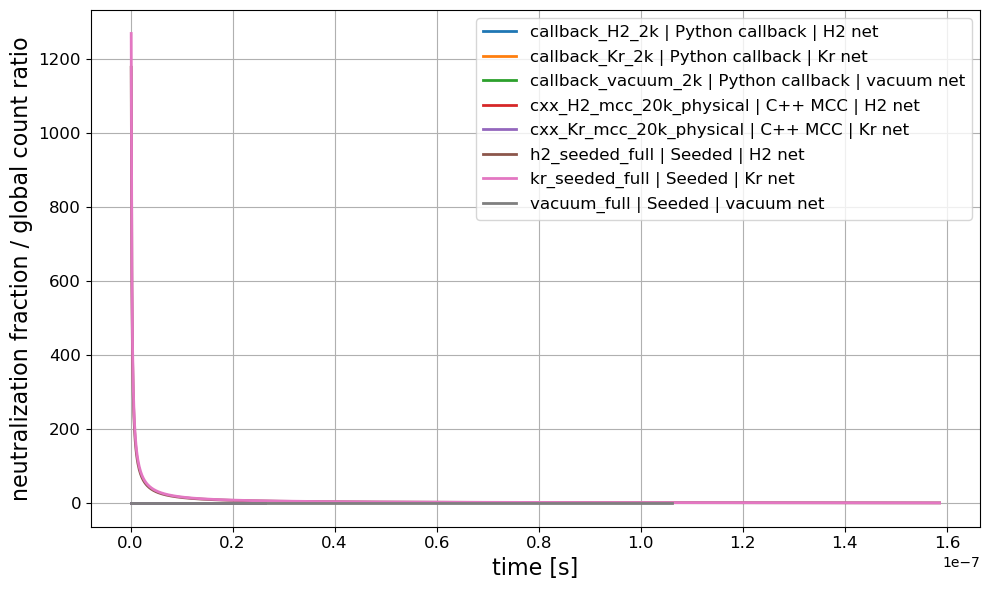

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/Cplusplus_MCC_neutralization.png


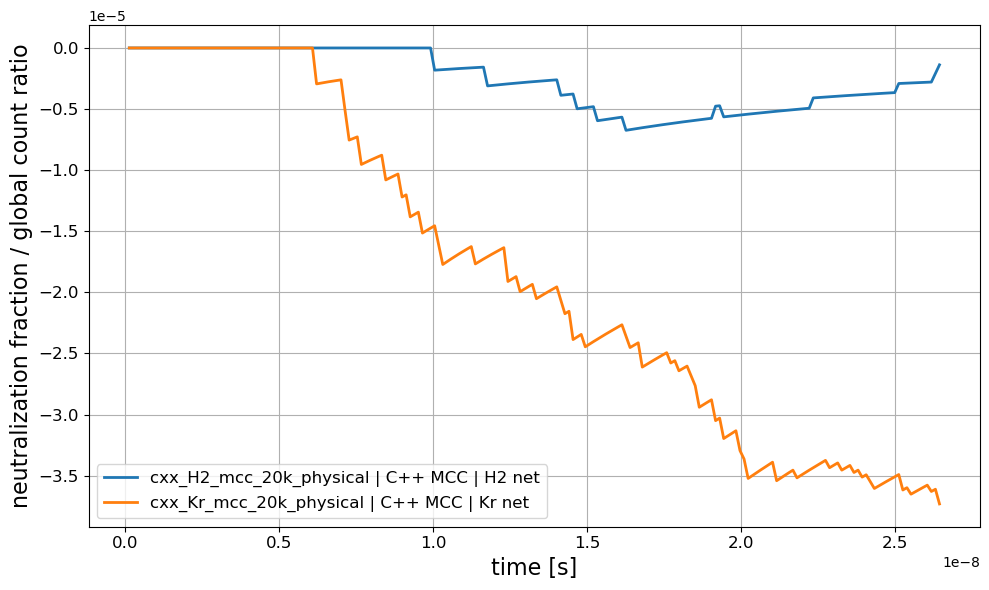

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/Python_callback_neutralization.png


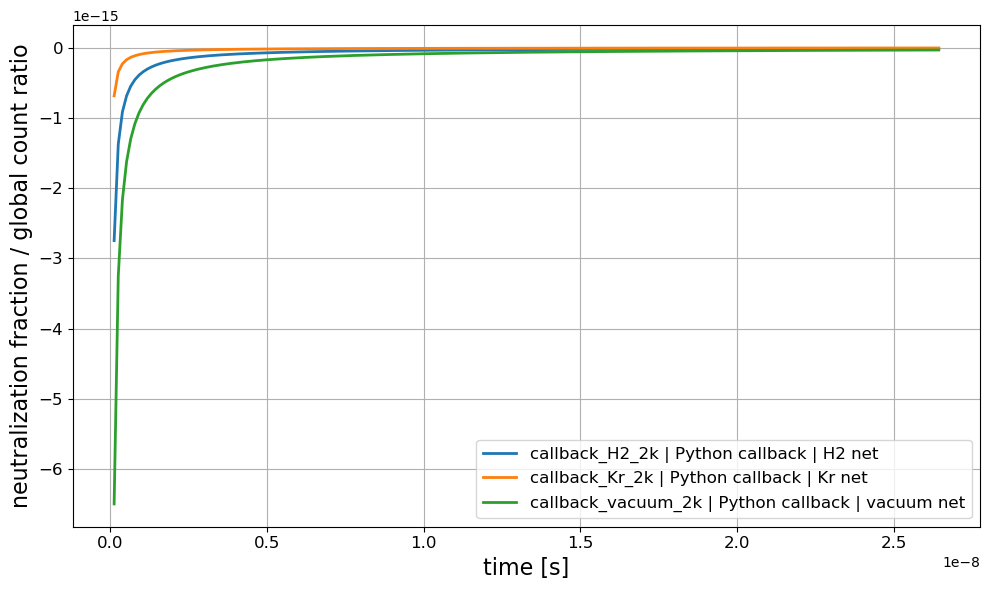

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/Seeded_neutralization.png


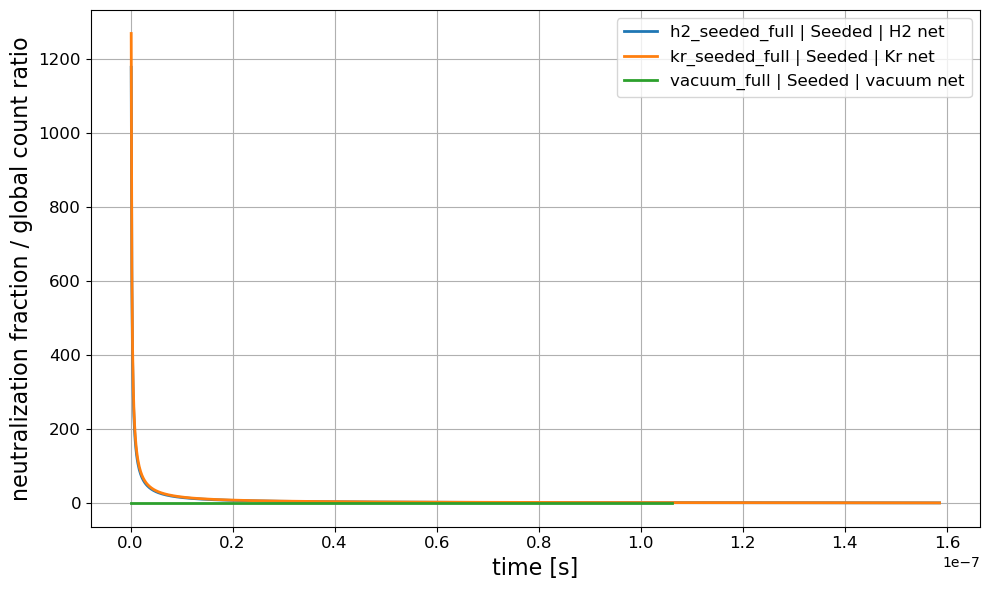

In [5]:
plot_neutralization_histories(cases, save_name="all_methods_global_neutralization.png")

for method in sorted(set(meta["method"] for _, _, _, meta in cases)):
    plot_neutralization_histories(
        cases,
        methods=[method],
        save_name=f"{method.replace(' ', '_').replace('+', 'plus')}_neutralization.png",
    )


## 4. Species populations


Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_H2_2k_species_populations.png


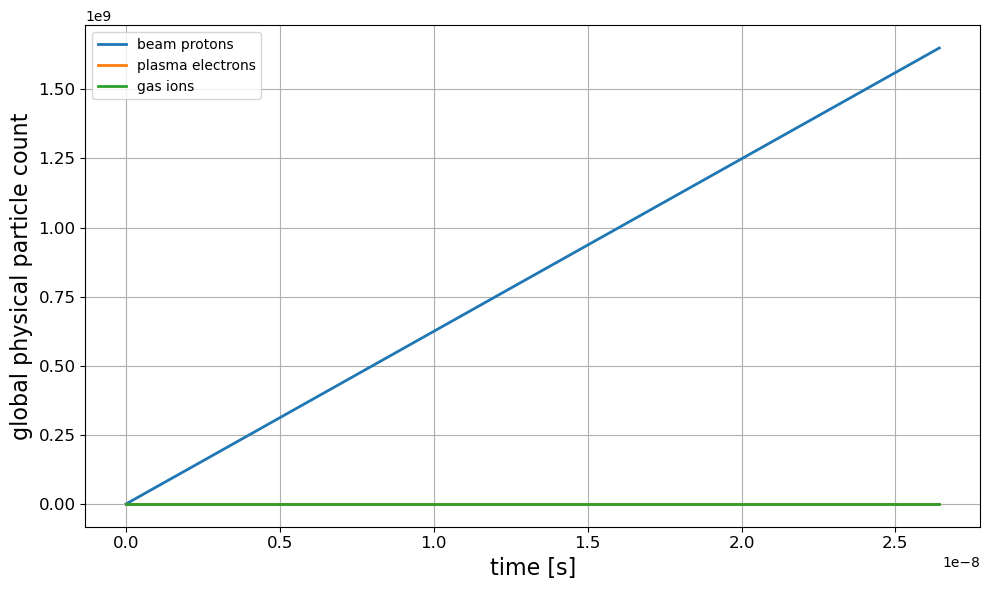

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_Kr_2k_species_populations.png


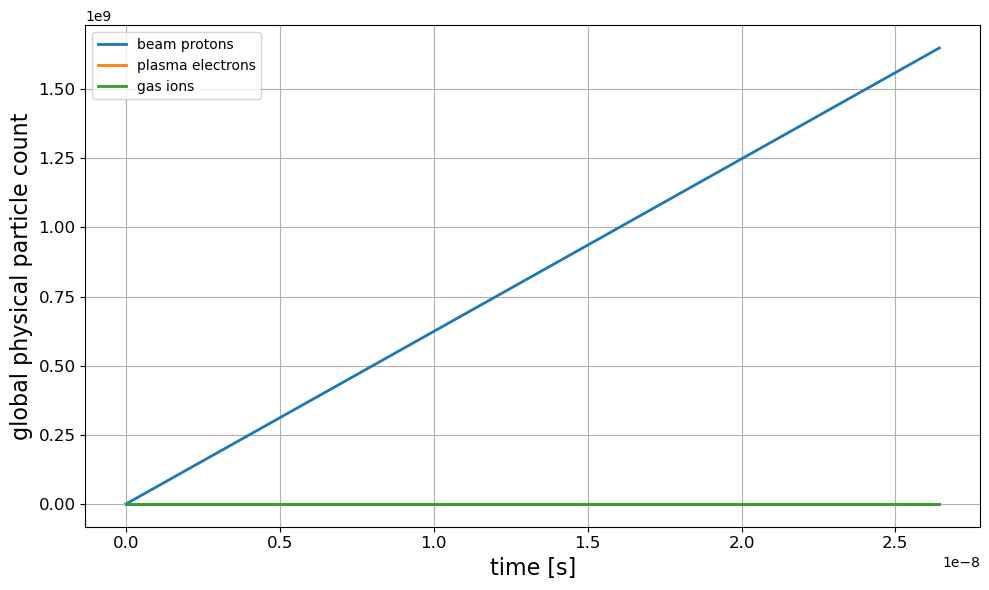

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_vacuum_2k_species_populations.png


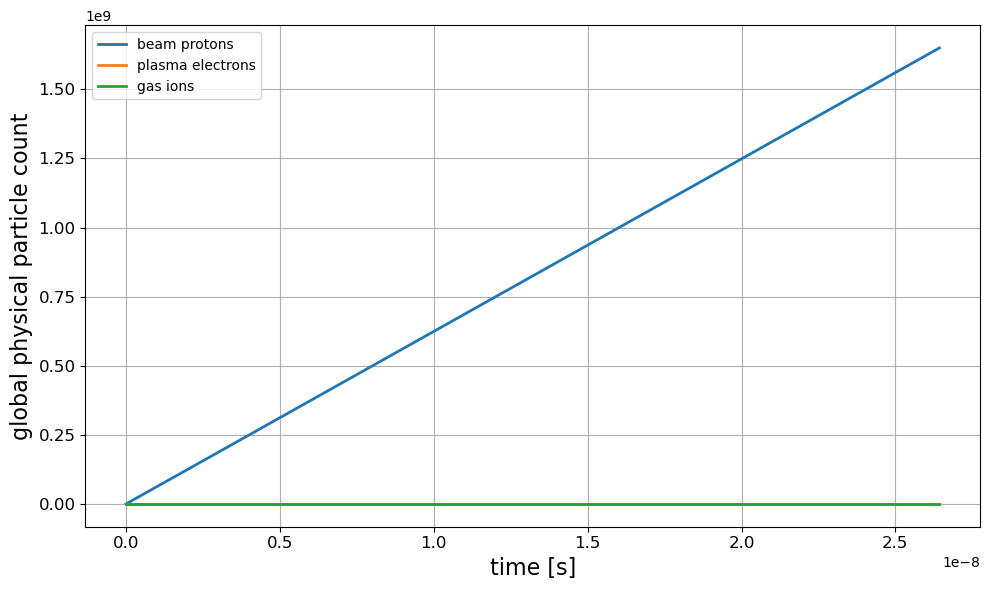

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/cxx_H2_mcc_20k_physical_species_populations.png


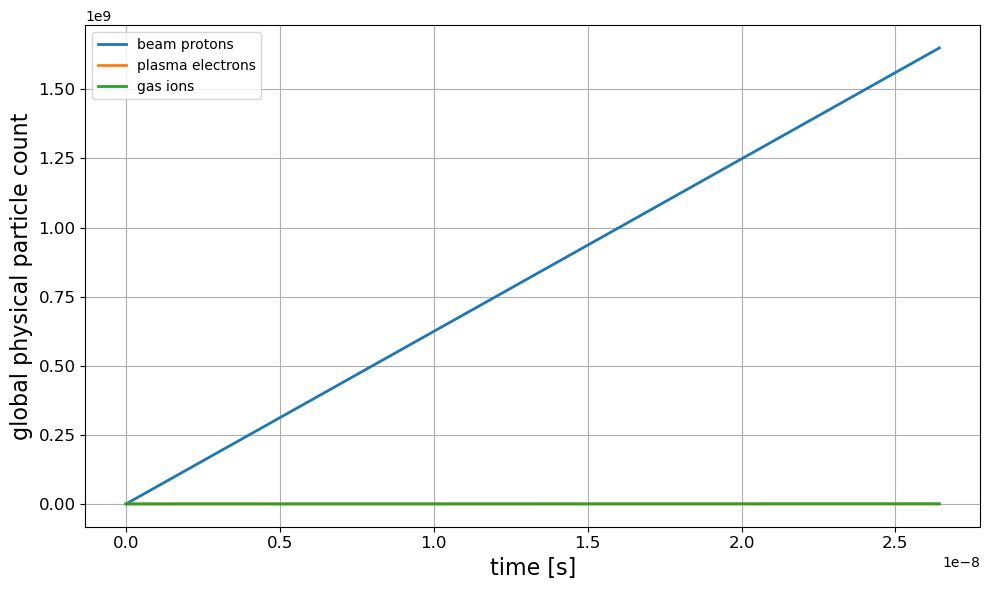

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/cxx_Kr_mcc_20k_physical_species_populations.png


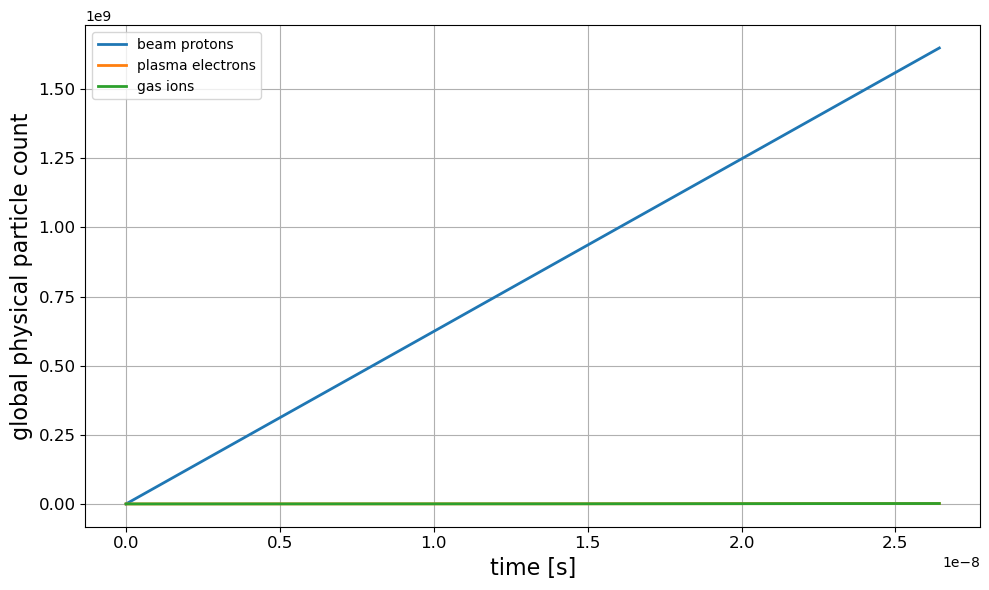

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/h2_seeded_full_species_populations.png


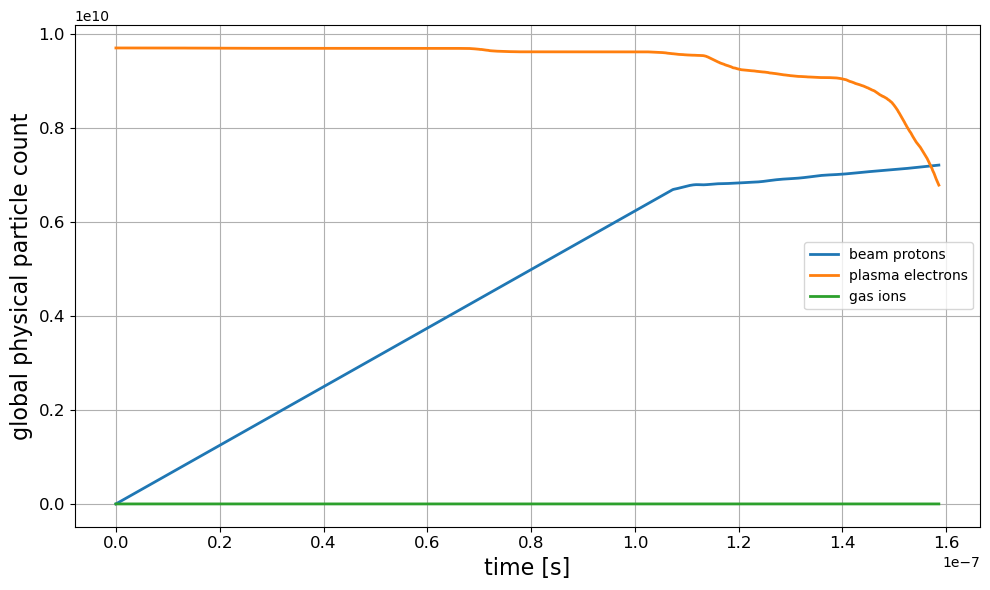

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/kr_seeded_full_species_populations.png


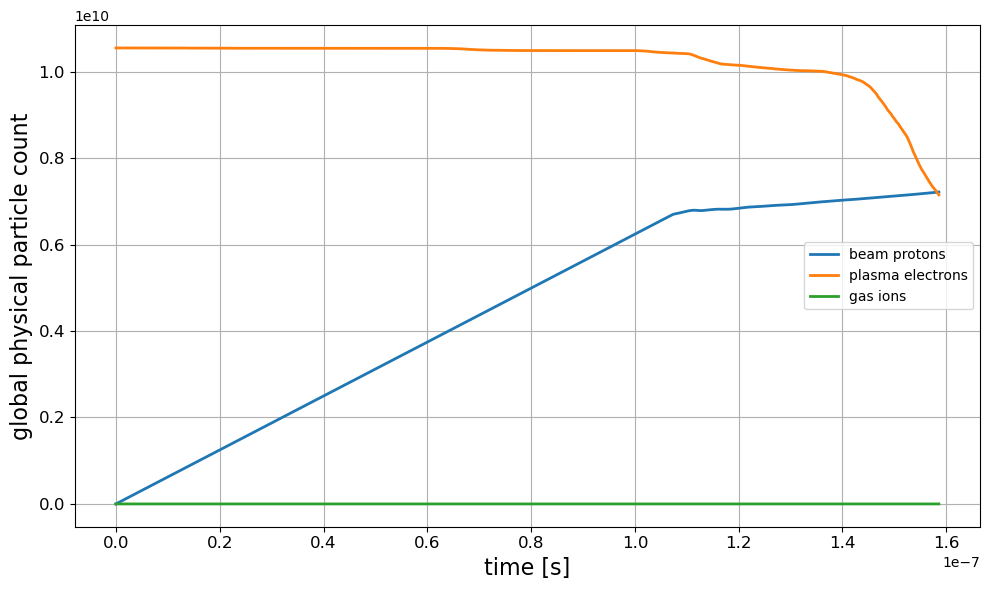

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/vacuum_full_species_populations.png


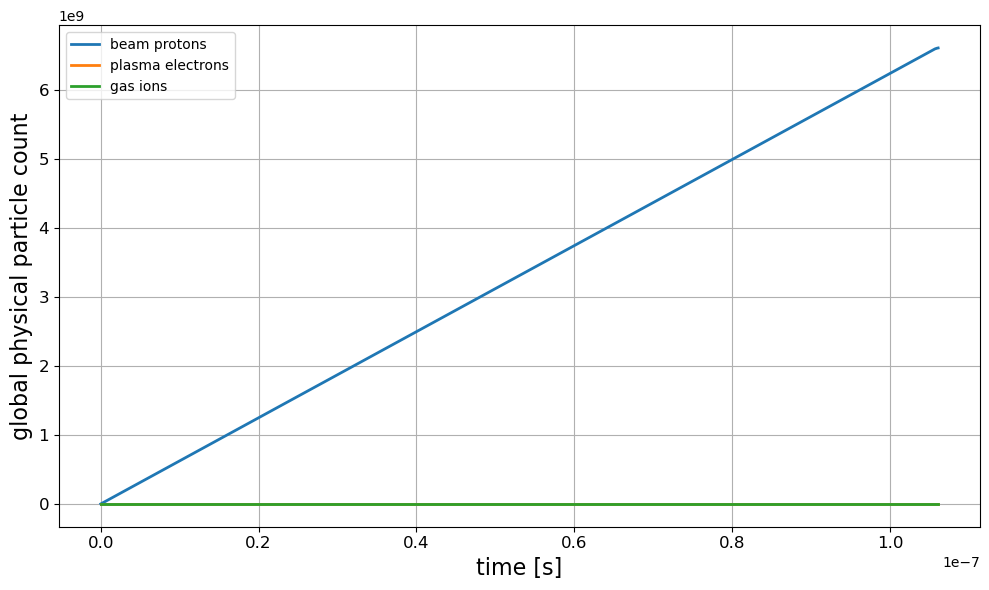

In [6]:
def plot_species_population(case_dir, hist, meta, save=True):
    plt.figure(figsize=(10, 6))
    plt.plot(hist["time_s"], hist["physical_beam_protons"], label="beam protons", linewidth=2)
    plt.plot(hist["time_s"], hist["physical_plasma_electrons"], label="plasma electrons", linewidth=2)
    plt.plot(hist["time_s"], hist["physical_gas_ions"], label="gas ions", linewidth=2)
    plt.xlabel("time [s]", fontsize=16)
    plt.ylabel("global physical particle count", fontsize=16)
    #plt.title(f"Species populations: {meta['case']} ({meta['method']}, {meta['gas']})", fontsize=16)
    plt.grid(True)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend()
    plt.tight_layout()
    if save:
        path = PLOTS_DIR / f"{meta['case']}_species_populations.png"
        plt.savefig(path, dpi=200)
        print("Saved:", path)
    plt.show()


for case_dir, hist, model, meta in cases:
    plot_species_population(case_dir, hist, meta)

## 5. Global ratio histories

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_H2_2k_global_ratios.png


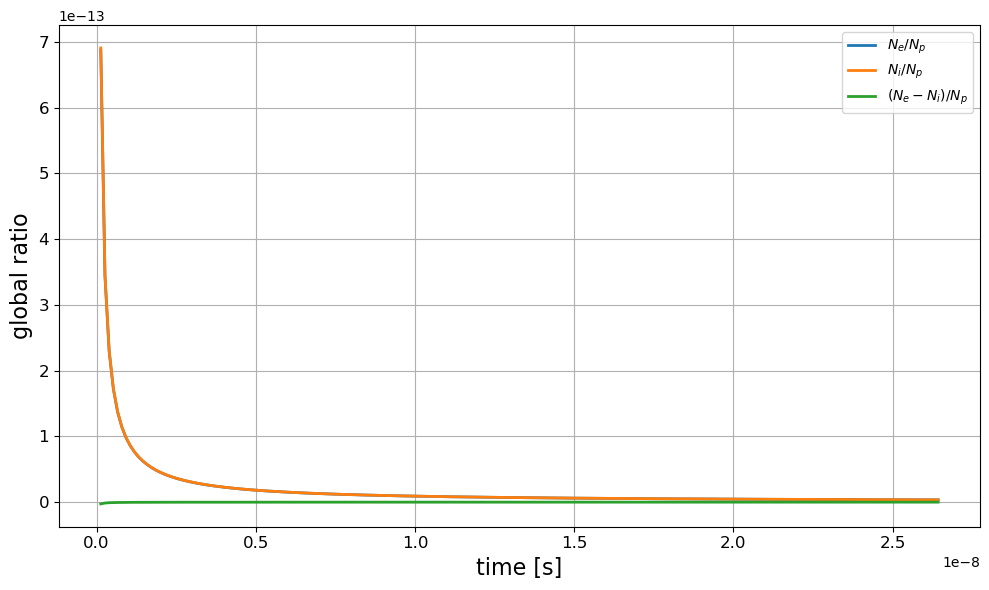

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_Kr_2k_global_ratios.png


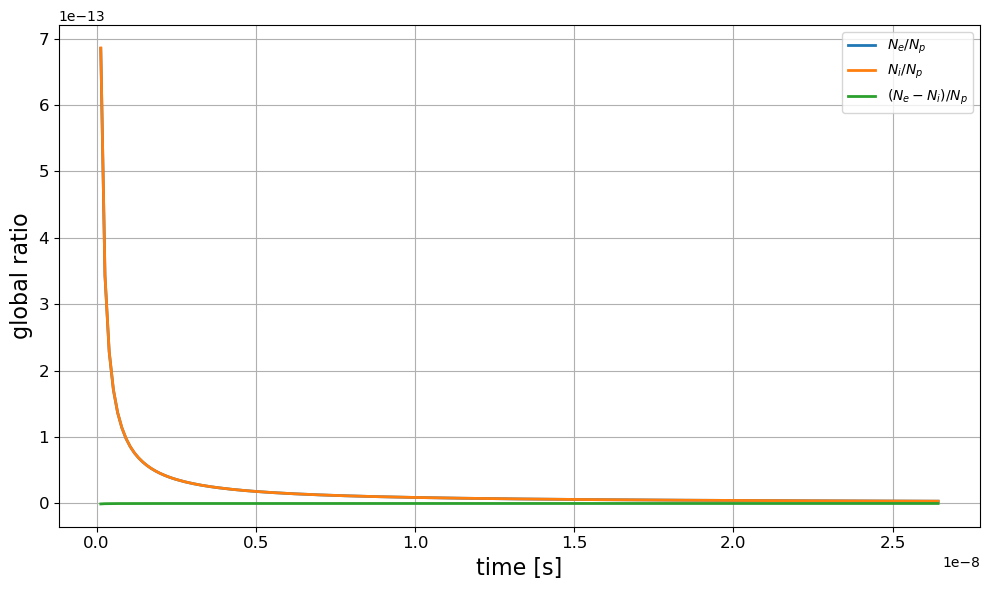

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_vacuum_2k_global_ratios.png


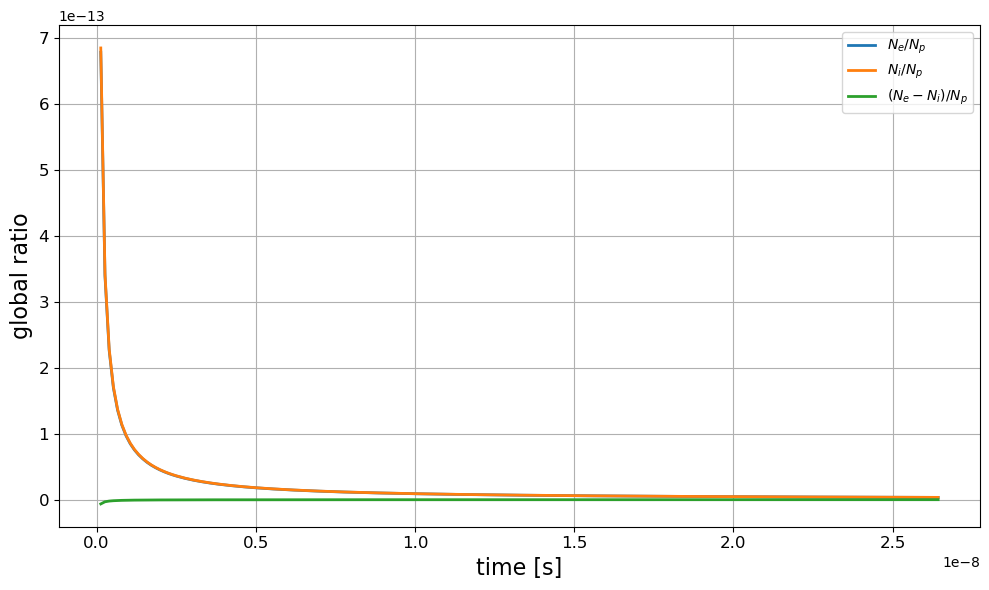

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/cxx_H2_mcc_20k_physical_global_ratios.png


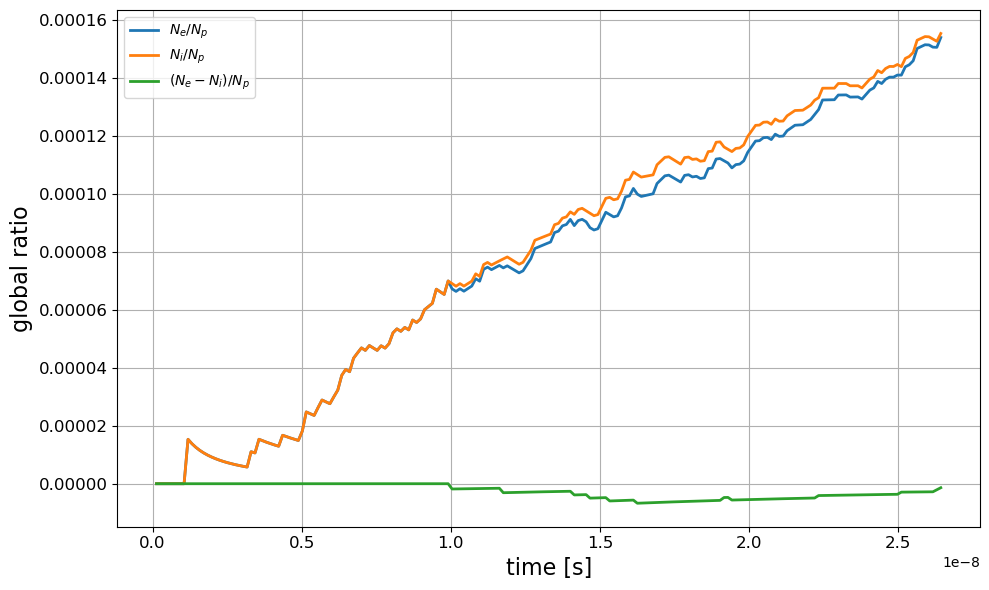

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/cxx_Kr_mcc_20k_physical_global_ratios.png


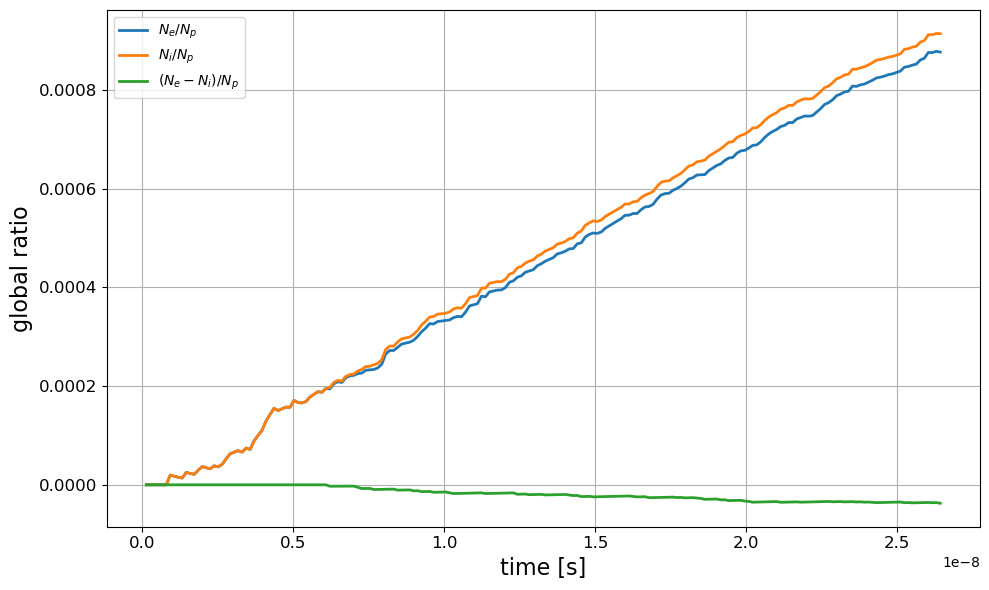

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/h2_seeded_full_global_ratios.png


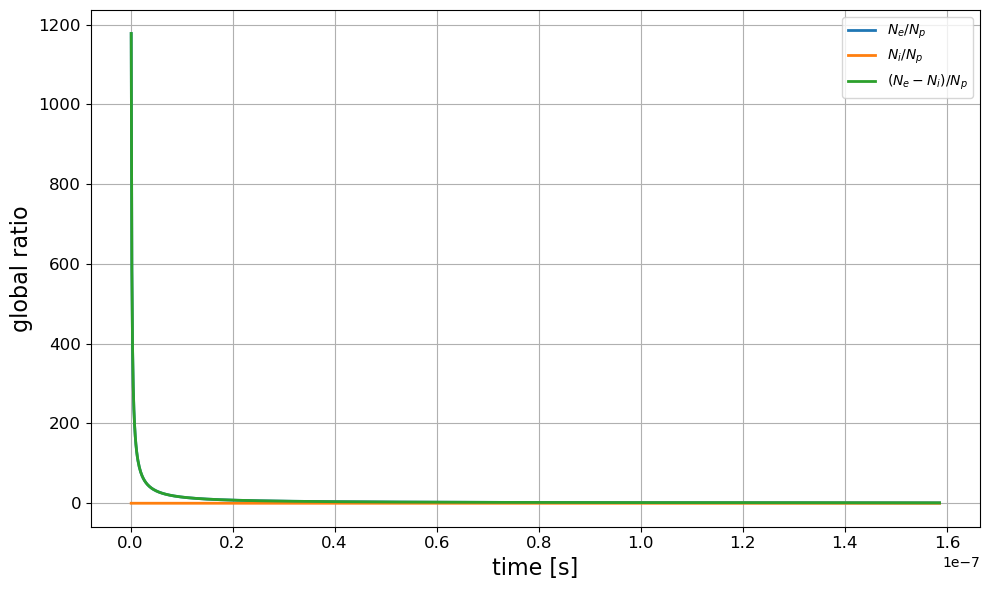

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/kr_seeded_full_global_ratios.png


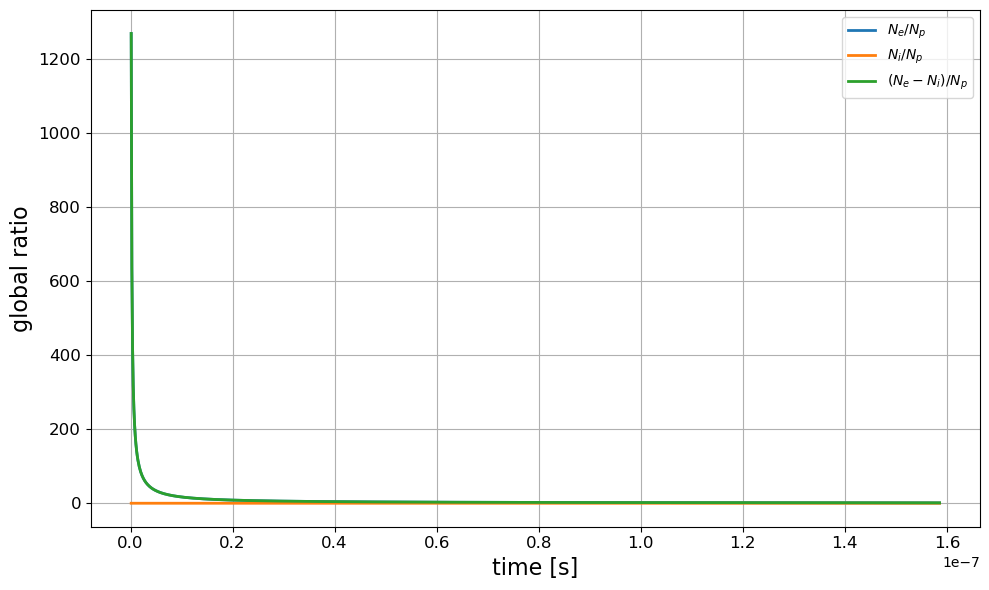

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/vacuum_full_global_ratios.png


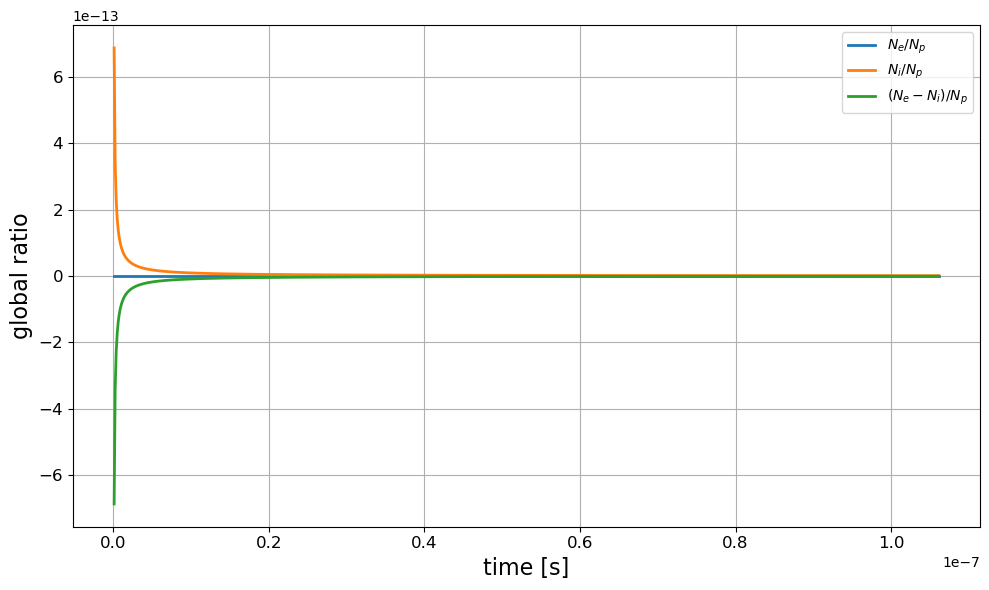

In [7]:
def plot_ratio_history(case_dir, hist, meta, save=True):
    plt.figure(figsize=(10, 6))
    plt.plot(hist["time_s"], hist["electron_over_proton"], label=r"$N_e/N_p$", linewidth=2)
    plt.plot(hist["time_s"], hist["ion_over_proton"], label=r"$N_i/N_p$", linewidth=2)
    plt.plot(hist["time_s"], hist["global_net_neutralization"], label=r"$(N_e-N_i)/N_p$", linewidth=2)
    plt.xlabel("time [s]", fontsize=16)
    plt.ylabel("global ratio", fontsize=16)
    #plt.title(f"Global particle ratios: {meta['case']} ({meta['method']}, {meta['gas']})", fontsize=16)
    plt.grid(True)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend()
    plt.tight_layout()
    if save:
        path = PLOTS_DIR / f"{meta['case']}_global_ratios.png"
        plt.savefig(path, dpi=200)
        print("Saved:", path)
    plt.show()


for case_dir, hist, model, meta in cases:
    plot_ratio_history(case_dir, hist, meta)

## 6. Dynamic source validation: pair-production ratio

For Python callback and C++ MCC cases:

\begin{equation}
\frac{\Delta N_e}{\Delta N_i}\approx 1.
\end{equation}

,case,method,gas,delta_Ne,delta_Ni,delta_Ne_over_delta_Ni,final_Ne_over_Np,final_Ni_over_Np,final_net
0,cxx_H2_mcc_20k_physical,C++ MCC,H2,2.540958e+05,2.563747e+05,0.991111,1.540341e-04,1.554156e-04,-1.381472e-06
1,cxx_Kr_mcc_20k_physical,C++ MCC,Kr,1.444814e+06,1.506344e+06,0.959153,8.762728e-04,9.135904e-04,-3.731761e-05
2,callback_H2_2k,Python callback,H2,0.000000e+00,0.000000e+00,NaN,3.427730e-15,3.441410e-15,-1.368014e-17
3,callback_Kr_2k,Python callback,Kr,0.000000e+00,0.000000e+00,NaN,3.422386e-15,3.425806e-15,-3.420675e-18
4,callback_vacuum_2k,Python callback,vacuum,-1.016440e-20,0.000000e+00,NaN,3.397501e-15,3.429997e-15,-3.249561e-17


Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/dynamic_source_pair_ratio.png


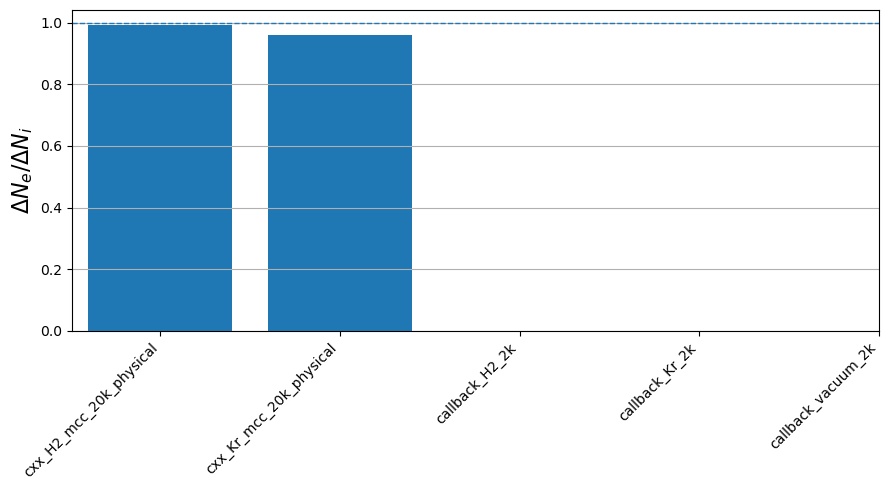

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/dynamic_source_final_Ne_over_Np.png


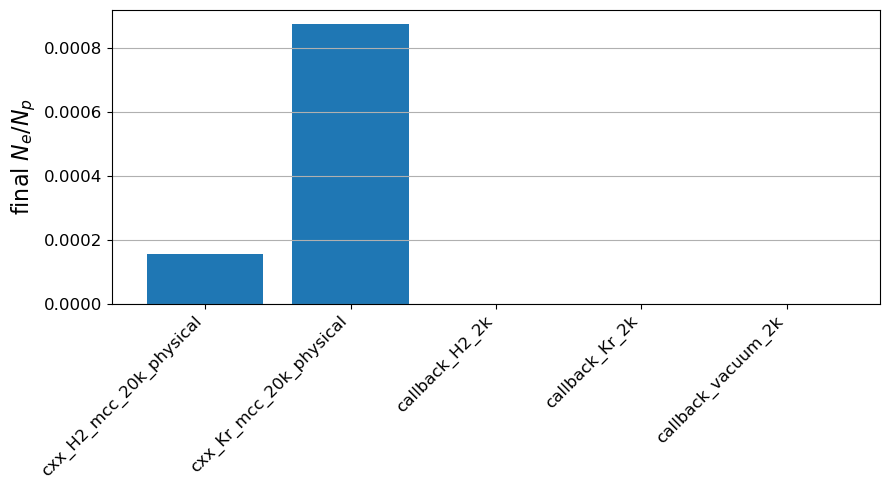

In [8]:
if len(summary):
    dynamic_summary = summary[summary["method"].isin(["Python callback", "C++ MCC"])].copy()
else:
    dynamic_summary = pd.DataFrame()

if dynamic_summary.empty:
    print("No Python callback or C++ MCC histories found.")
else:
    display(dynamic_summary[[
        "case", "method", "gas", "delta_Ne", "delta_Ni",
        "delta_Ne_over_delta_Ni", "final_Ne_over_Np", "final_Ni_over_Np", "final_net",
    ]])

    plt.figure(figsize=(9, 5))
    x = np.arange(len(dynamic_summary))
    plt.bar(x, dynamic_summary["delta_Ne_over_delta_Ni"])
    plt.axhline(1.0, linestyle="--", linewidth=1)
    plt.xticks(x, dynamic_summary["case"], rotation=45, ha="right")
    plt.ylabel(r"$\Delta N_e/\Delta N_i$", fontsize=16)
    #plt.title("Electron-ion pair-production check", fontsize=16)
    plt.grid(True, axis="y")
    plt.tight_layout()
    path = PLOTS_DIR / "dynamic_source_pair_ratio.png"
    plt.savefig(path, dpi=200)
    print("Saved:", path)
    plt.show()

    plt.figure(figsize=(9, 5))
    x = np.arange(len(dynamic_summary))
    plt.bar(x, dynamic_summary["final_Ne_over_Np"])
    plt.xticks(x, dynamic_summary["case"], rotation=45, ha="right", fontsize=12)
    plt.ylabel(r"final $N_e/N_p$", fontsize=16)
    #plt.title("Dynamic source strength indicator", fontsize=16)
    plt.grid(True, axis="y")
    plt.yticks(fontsize=12)
    plt.tight_layout()
    path = PLOTS_DIR / "dynamic_source_final_Ne_over_Np.png"
    plt.savefig(path, dpi=200)
    print("Saved:", path)
    plt.show()

## 7. H₂ versus Kr comparison

Kr should produce a larger source rate than H₂ at the same pressure because its proton-impact ionization cross section is larger.

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/h2_vs_kr_final_Ne_over_Np.png


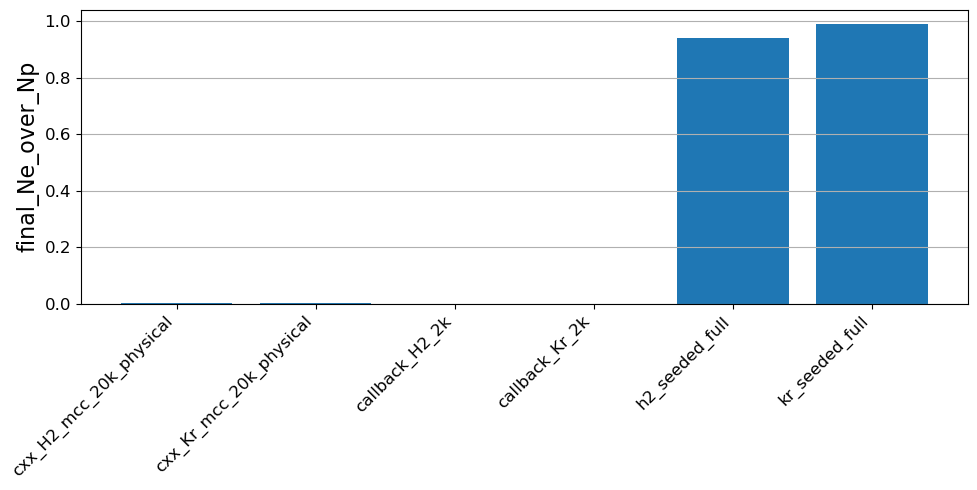

In [9]:
if len(summary):
    metric = "final_Ne_over_Np"
    plot_df = summary[summary["gas"].isin(["H2", "Kr"])].copy()

    if not plot_df.empty:
        plt.figure(figsize=(10, 5))
        x = np.arange(len(plot_df))
        plt.bar(x, plot_df[metric])
        plt.xticks(x, plot_df["case"], rotation=45, ha="right", fontsize=12)
        plt.ylabel(metric, fontsize=16)
        #plt.title("H2 vs Kr electron production / compensation indicator", fontsize=16)
        plt.grid(True, axis="y")
        plt.yticks(fontsize=12)
        plt.tight_layout()
        path = PLOTS_DIR / "h2_vs_kr_final_Ne_over_Np.png"
        plt.savefig(path, dpi=200)
        print("Saved:", path)
        plt.show()

## 8. Simulation-time coverage

For the current 30 keV proton case, use $v_b\approx 2.397\times10^6\ \mathrm{m/s}$. The estimated distance covered is:

\begin{equation}
L_{\rm sim} \approx v_b t_{\rm final}.
\end{equation}

,case,method,gas,final_time_s,estimated_distance_m,domain_fraction
0,callback_H2_2k,Python callback,H2,2.642807e-08,0.063356,0.243676
1,callback_Kr_2k,Python callback,Kr,2.642807e-08,0.063356,0.243676
2,callback_vacuum_2k,Python callback,vacuum,2.642807e-08,0.063356,0.243676
3,cxx_H2_mcc_20k_physical,C++ MCC,H2,2.642807e-08,0.063356,0.243676
4,cxx_Kr_mcc_20k_physical,C++ MCC,Kr,2.642807e-08,0.063356,0.243676
5,h2_seeded_full,Seeded,H2,1.585684e-07,0.380135,1.462059
6,kr_seeded_full,Seeded,Kr,1.585684e-07,0.380135,1.462059
7,vacuum_full,Seeded,vacuum,1.061087e-07,0.254374,0.978361


Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/simulation_time_coverage.png


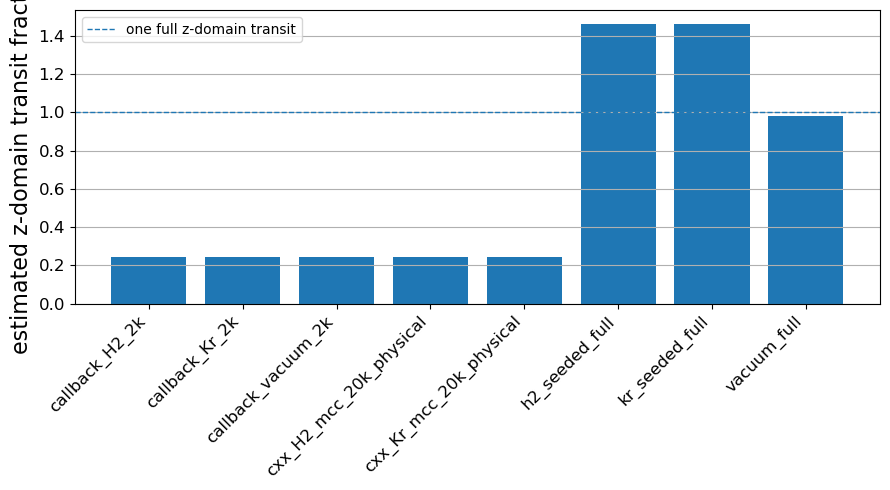

In [10]:
v_proton_m_per_s = 2.397295197e6
z_domain_length_m = 0.24 - (-0.02)

coverage_rows = []
for case_dir, hist, model, meta in cases:
    t_final = float(hist["time_s"].dropna().iloc[-1])
    distance = v_proton_m_per_s * t_final
    coverage_rows.append({
        "case": meta["case"],
        "method": meta["method"],
        "gas": meta["gas"],
        "final_time_s": t_final,
        "estimated_distance_m": distance,
        "domain_fraction": distance / z_domain_length_m,
    })

coverage = pd.DataFrame(coverage_rows)
display(coverage)

if len(coverage):
    plt.figure(figsize=(9, 5))
    x = np.arange(len(coverage))
    plt.bar(x, coverage["domain_fraction"])
    plt.axhline(1.0, linestyle="--", linewidth=1, label="one full z-domain transit")
    plt.xticks(x, coverage["case"], rotation=45, ha="right", fontsize=12)
    plt.ylabel("estimated z-domain transit fraction", fontsize=16)
    #plt.title("Simulation-time coverage", fontsize=16)
    plt.grid(True, axis="y")
    plt.yticks(fontsize=12)
    plt.legend()
    plt.tight_layout()
    path = PLOTS_DIR / "simulation_time_coverage.png"
    plt.savefig(path, dpi=200)
    print("Saved:", path)
    plt.show()

## 9. IOTA-style neutralization-time plot

This plot mirrors the older electron-column style of plotting electron build-up versus time, but here it uses global particle-count ratios from the current WarpX simulations.

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/iota_style_neutralization_time_comparison.png


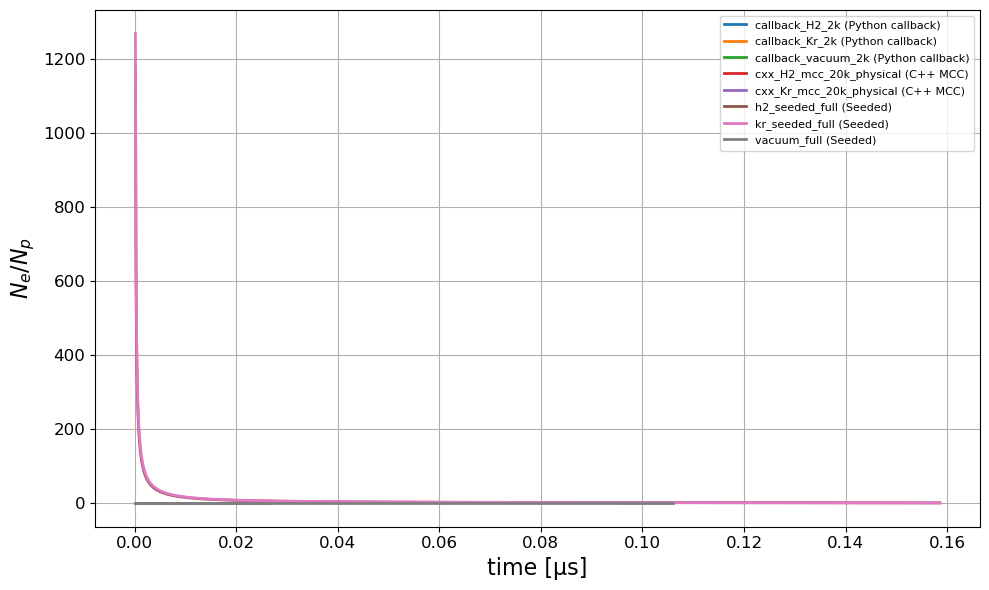

In [11]:
plt.figure(figsize=(10, 6))
any_curve = False
for case_dir, hist, model, meta in cases:
    y = hist["electron_over_proton"].to_numpy()
    if np.all(~np.isfinite(y)):
        continue
    plt.plot(hist["time_s"] * 1e6, y, label=f"{meta['case']} ({meta['method']})", linewidth=2)
    any_curve = True

plt.xlabel("time [µs]", fontsize=16)
plt.ylabel(r"$N_e/N_p$", fontsize=16)
#plt.title("Neutralization/source-growth comparison", fontsize=16)
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
if any_curve:
    plt.legend(fontsize=8)
plt.tight_layout()
path = PLOTS_DIR / "iota_style_neutralization_time_comparison.png"
plt.savefig(path, dpi=200)
print("Saved:", path)
plt.show()

## 10. Optional plotfile analysis: transverse and longitudinal profiles

This section attempts to read WarpX plotfiles using `yt`. It is optional. If `yt` is unavailable or plotfiles are absent, the cells skip gracefully.

The output profiles are useful for reproducing electron-column-style comparisons of proton, electron, and gas-ion density profiles.

In [12]:
def find_plotfiles(case_dir: Path):
    candidates = []
    for pattern in ["diags/diag*", "plt*", "diags/plt*"]:
        candidates.extend(case_dir.glob(pattern))
    candidates = [p for p in candidates if p.is_dir()]
    def plotfile_index(p):
        m = re.search(r"(\d+)$", p.name)
        return int(m.group(1)) if m else -1
    return sorted(candidates, key=plotfile_index)


plotfile_catalog = {}
for case_dir, hist, model, meta in cases:
    pfs = find_plotfiles(case_dir)
    if pfs:
        plotfile_catalog[meta["case"]] = pfs
        print(meta["case"], "plotfiles:", len(pfs), "latest:", pfs[-1])
    else:
        print(meta["case"], "plotfiles: none found")


try:
    import yt
    yt.set_log_level("ERROR")
    YT_AVAILABLE = True
except Exception as exc:
    yt = None
    YT_AVAILABLE = False
    print("yt unavailable:", exc)

callback_H2_2k plotfiles: 5 latest: /home/cspark/Work/projects/plasma_column/simulations/runs/callback_H2_2k/diags/diag1020000
callback_Kr_2k plotfiles: 5 latest: /home/cspark/Work/projects/plasma_column/simulations/runs/callback_Kr_2k/diags/diag1020000
callback_vacuum_2k plotfiles: 5 latest: /home/cspark/Work/projects/plasma_column/simulations/runs/callback_vacuum_2k/diags/diag1020000
cxx_H2_mcc_20k_physical plotfiles: 5 latest: /home/cspark/Work/projects/plasma_column/simulations/runs/cxx_H2_mcc_20k_physical/diags/diag1020000
cxx_Kr_mcc_20k_physical plotfiles: 5 latest: /home/cspark/Work/projects/plasma_column/simulations/runs/cxx_Kr_mcc_20k_physical/diags/diag1020000
h2_seeded_full plotfiles: 25 latest: /home/cspark/Work/projects/plasma_column/simulations/runs/h2_seeded_full/diags/diag1120000
kr_seeded_full plotfiles: 25 latest: /home/cspark/Work/projects/plasma_column/simulations/runs/kr_seeded_full/diags/diag1120000
vacuum_full plotfiles: 17 latest: /home/cspark/Work/projects/plas

callback_H2_2k beam_protons
callback_H2_2k plasma_electrons
callback_Kr_2k beam_protons
callback_Kr_2k plasma_electrons
callback_vacuum_2k beam_protons
callback_vacuum_2k plasma_electrons
cxx_H2_mcc_20k_physical beam_protons
cxx_H2_mcc_20k_physical plasma_electrons
cxx_H2_mcc_20k_physical gas_ions
cxx_Kr_mcc_20k_physical beam_protons
cxx_Kr_mcc_20k_physical plasma_electrons
h2_seeded_full beam_protons
h2_seeded_full plasma_electrons
h2_seeded_full gas_ions
kr_seeded_full beam_protons
kr_seeded_full plasma_electrons
vacuum_full beam_protons
vacuum_full gas_ions
Analyzing: callback_H2_2k /home/cspark/Work/projects/plasma_column/simulations/runs/callback_H2_2k/diags/diag1020000
Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_H2_2k_diag1020000_transverse_profile.png


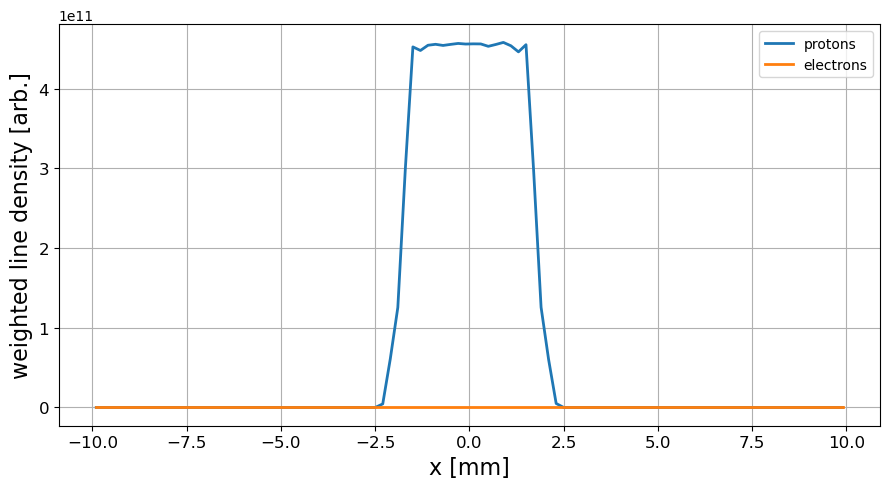

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_H2_2k_diag1020000_longitudinal_profile.png


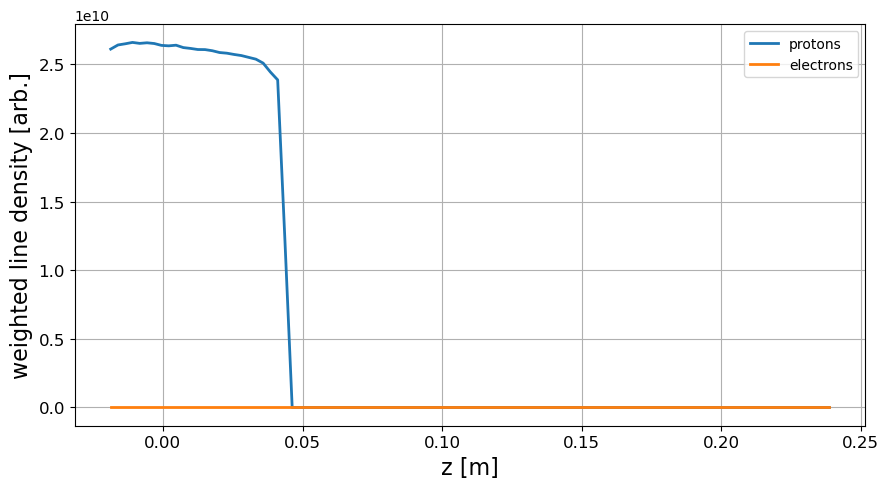

Analyzing: callback_Kr_2k /home/cspark/Work/projects/plasma_column/simulations/runs/callback_Kr_2k/diags/diag1020000
Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_Kr_2k_diag1020000_transverse_profile.png


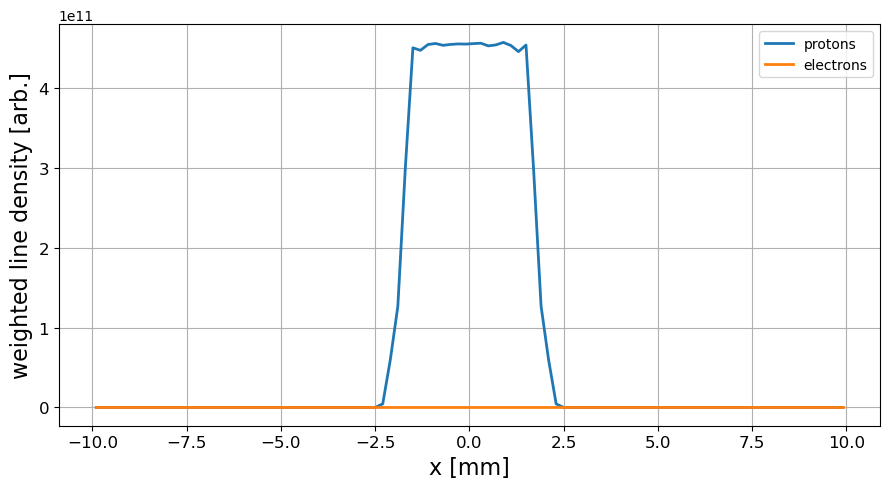

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_Kr_2k_diag1020000_longitudinal_profile.png


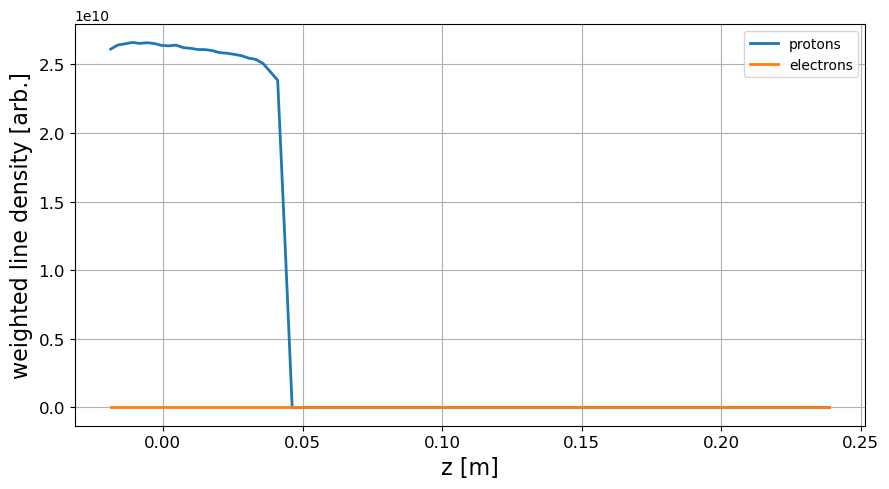

Analyzing: callback_vacuum_2k /home/cspark/Work/projects/plasma_column/simulations/runs/callback_vacuum_2k/diags/diag1020000
Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_vacuum_2k_diag1020000_transverse_profile.png


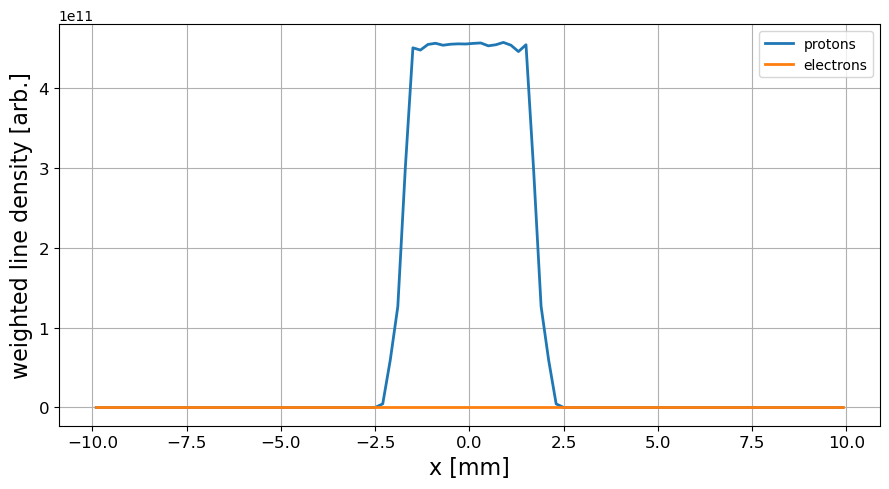

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_vacuum_2k_diag1020000_longitudinal_profile.png


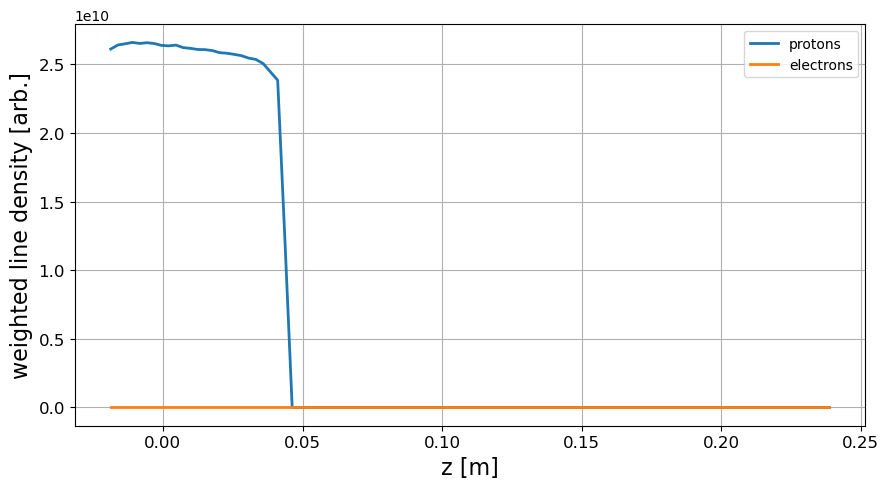

Analyzing: cxx_H2_mcc_20k_physical /home/cspark/Work/projects/plasma_column/simulations/runs/cxx_H2_mcc_20k_physical/diags/diag1020000
Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/cxx_H2_mcc_20k_physical_diag1020000_transverse_profile.png


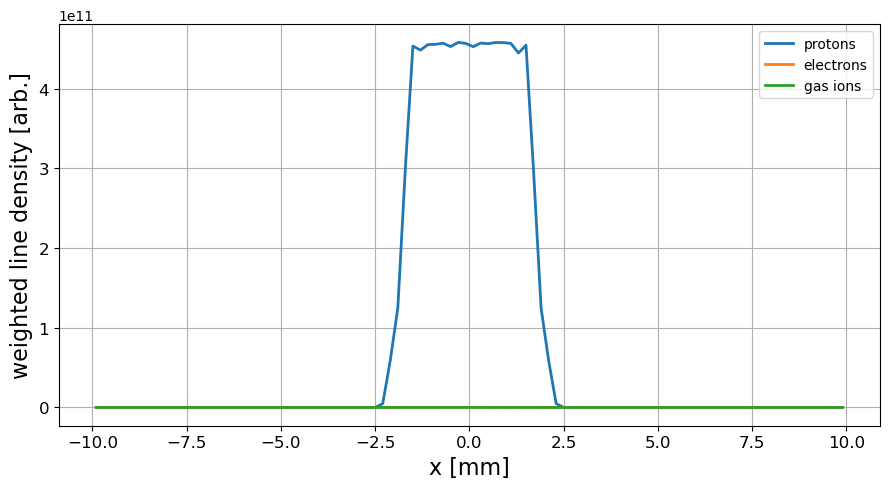

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/cxx_H2_mcc_20k_physical_diag1020000_longitudinal_profile.png


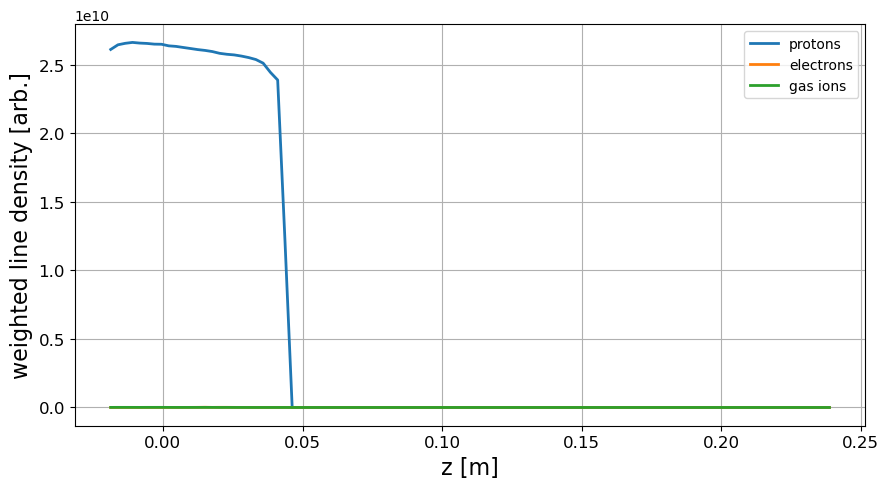

Analyzing: cxx_Kr_mcc_20k_physical /home/cspark/Work/projects/plasma_column/simulations/runs/cxx_Kr_mcc_20k_physical/diags/diag1020000
Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/cxx_Kr_mcc_20k_physical_diag1020000_transverse_profile.png


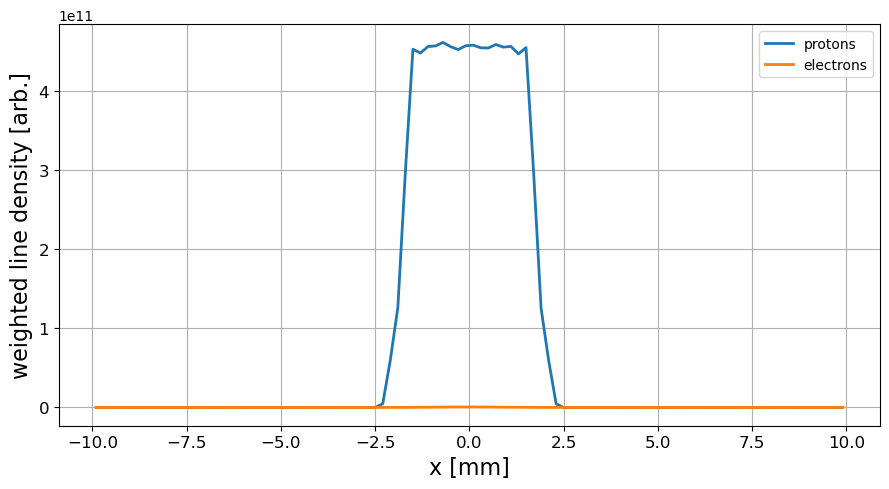

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/cxx_Kr_mcc_20k_physical_diag1020000_longitudinal_profile.png


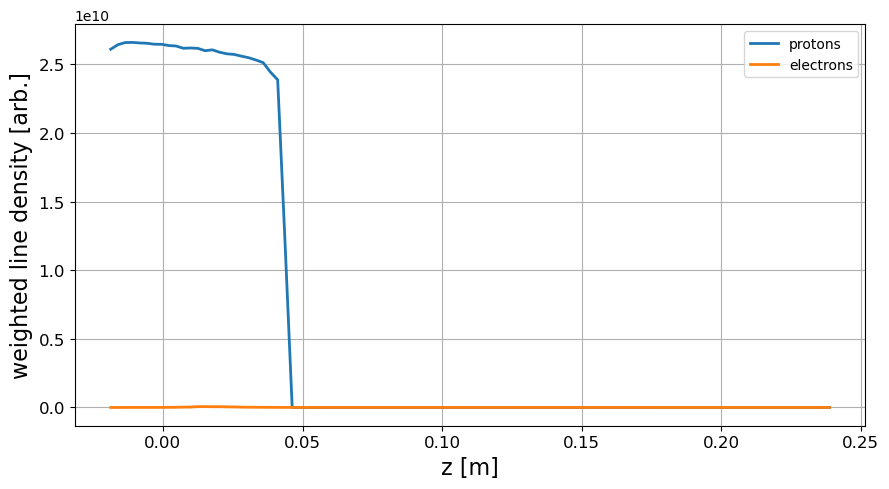

Analyzing: h2_seeded_full /home/cspark/Work/projects/plasma_column/simulations/runs/h2_seeded_full/diags/diag1120000
Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/h2_seeded_full_diag1120000_transverse_profile.png


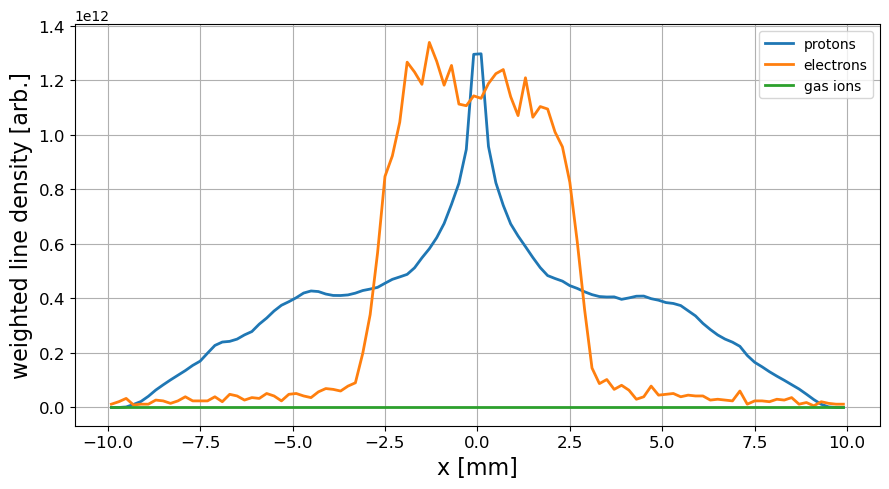

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/h2_seeded_full_diag1120000_longitudinal_profile.png


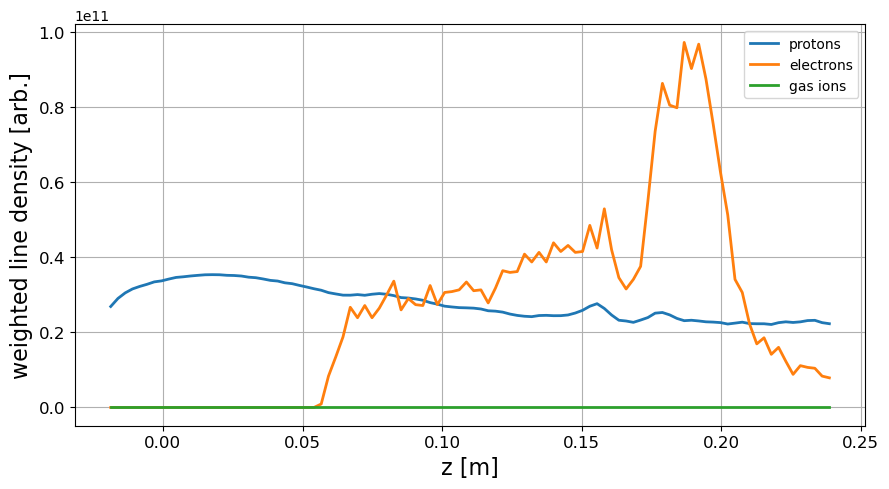

Analyzing: kr_seeded_full /home/cspark/Work/projects/plasma_column/simulations/runs/kr_seeded_full/diags/diag1120000
Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/kr_seeded_full_diag1120000_transverse_profile.png


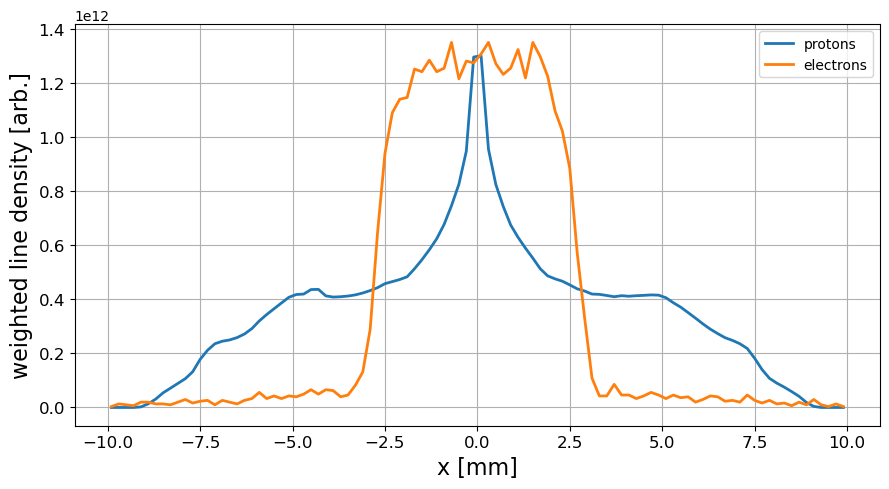

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/kr_seeded_full_diag1120000_longitudinal_profile.png


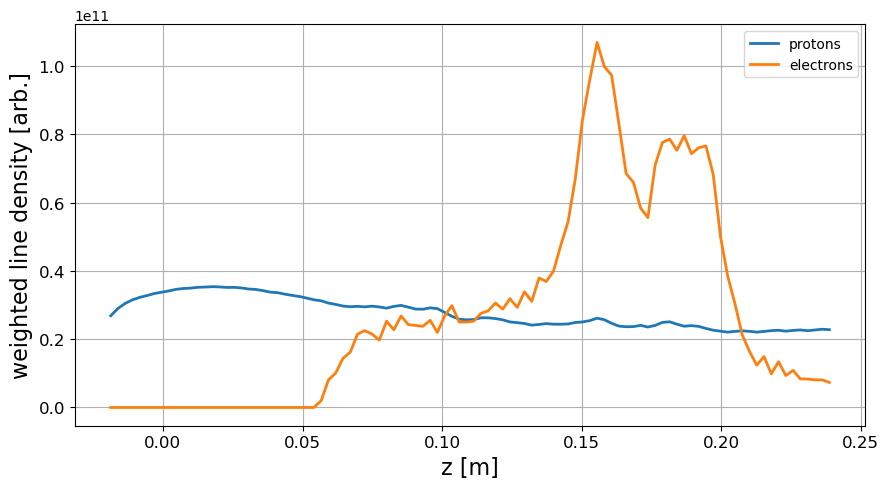

Analyzing: vacuum_full /home/cspark/Work/projects/plasma_column/simulations/runs/vacuum_full/diags/diag1080000
Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/vacuum_full_diag1080000_transverse_profile.png


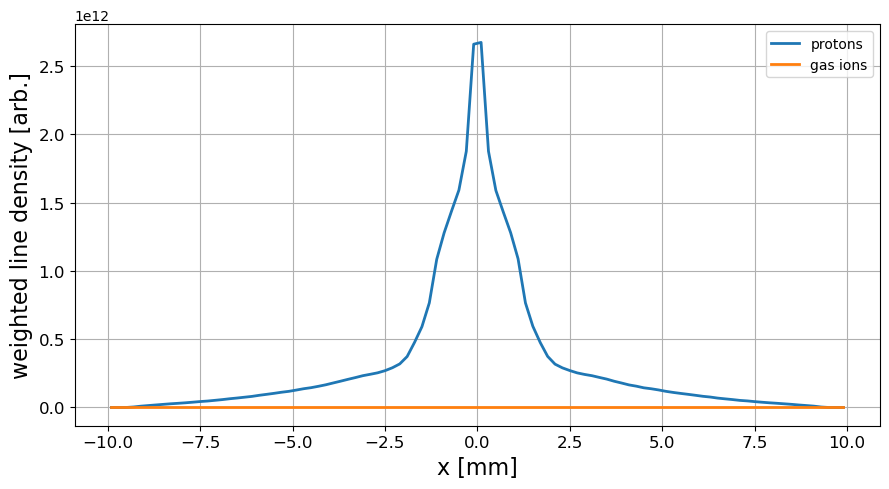

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/vacuum_full_diag1080000_longitudinal_profile.png


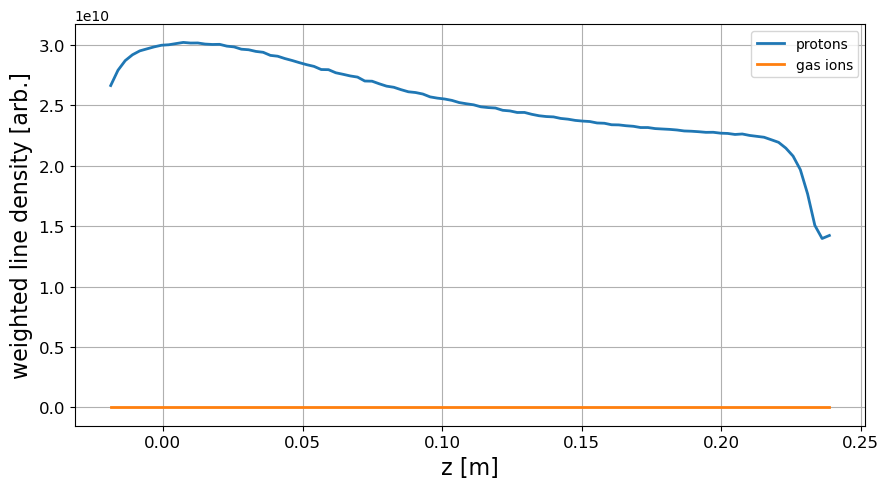

In [13]:
def get_particle_arrays_from_plotfile(plotfile: Path, species_names=("beam_protons", "plasma_electrons", "gas_ions")):
    if not YT_AVAILABLE:
        return {}

    ds = yt.load(str(plotfile))
    ad = ds.all_data()
    result = {}

    fields = set(ds.field_list)

    for sp in species_names:
        def find_field(possible):
            for f in possible:
                if f in fields:
                    return f
            return None

        fx = find_field([(sp, "particle_position_x"), (sp, "particle_x"), (sp, "x")])
        fy = find_field([(sp, "particle_position_y"), (sp, "particle_y"), (sp, "y")])
        fz = find_field([(sp, "particle_position_z"), (sp, "particle_z"), (sp, "z")])
        fw = find_field([(sp, "particle_weight"), (sp, "particle_weighting"), (sp, "weighting")])

        if fx is None or fy is None or fz is None:
            continue

        try:
            x = np.asarray(ad[fx])
            y = np.asarray(ad[fy])
            z = np.asarray(ad[fz])
            w = np.asarray(ad[fw]) if fw is not None else np.ones_like(x)
            result[sp] = {"x": x, "y": y, "z": z, "w": w}
        except Exception as exc:
            print(f"Could not read {sp} from {plotfile}: {exc}")

    return result


def weighted_profile(values, weights, bins, density=False):
    hist, edges = np.histogram(values, bins=bins, weights=weights)
    centers = 0.5 * (edges[:-1] + edges[1:])
    if density:
        widths = np.diff(edges)
        hist = hist / widths
    return centers, hist


def plot_transverse_longitudinal_profiles(case_name: str, plotfile: Path, bins_x=None, bins_z=None):
    if bins_x is None:
        bins_x = np.linspace(-0.01, 0.01, 101)
    if bins_z is None:
        bins_z = np.linspace(-0.02, 0.24, 101)

    arrays = get_particle_arrays_from_plotfile(plotfile)
    if not arrays:
        print(f"No particle arrays found for {case_name} in {plotfile}")
        return

    label_map = {
        "beam_protons": "protons",
        "plasma_electrons": "electrons",
        "gas_ions": "gas ions",
    }

    plt.figure(figsize=(9, 5))
    for sp, arr in arrays.items():
        cx, hx = weighted_profile(arr["x"], arr["w"], bins_x, density=True)
        plt.plot(cx * 1e3, hx, label=label_map.get(sp, sp), linewidth=2)
    plt.xlabel("x [mm]", fontsize=16)
    plt.ylabel("weighted line density [arb.]", fontsize=16)
    #plt.title(f"Transverse profile: {case_name} | {plotfile.name}", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = PLOTS_DIR / f"{case_name}_{plotfile.name}_transverse_profile.png"
    plt.savefig(path, dpi=200)
    print("Saved:", path)
    plt.show()

    plt.figure(figsize=(9, 5))
    for sp, arr in arrays.items():
        cz, hz = weighted_profile(arr["z"], arr["w"], bins_z, density=True)
        plt.plot(cz, hz, label=label_map.get(sp, sp), linewidth=2)
    plt.xlabel("z [m]", fontsize=16)
    plt.ylabel("weighted line density [arb.]", fontsize=16)
    #plt.title(f"Longitudinal profile: {case_name} | {plotfile.name}", fontsize=16)
    plt.grid(True)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend()
    plt.tight_layout()
    path = PLOTS_DIR / f"{case_name}_{plotfile.name}_longitudinal_profile.png"
    plt.savefig(path, dpi=200)
    print("Saved:", path)
    plt.show()

label_map = {
        "beam_protons": "protons",
        "plasma_electrons": "electrons",
        "gas_ions": "gas ions",
    }
for case_name, pfs in plotfile_catalog.items():
    arrays = get_particle_arrays_from_plotfile(pfs[-1])
    for sp, arr in arrays.items():
        print (case_name, sp)
        
if not YT_AVAILABLE:
    print("Skipping plotfile profile analysis because yt is unavailable.")
else:
    for case_name, pfs in plotfile_catalog.items():
        latest = pfs[-1]
        print("Analyzing:", case_name, latest)
        plot_transverse_longitudinal_profiles(case_name, latest)

## 11. Save analysis manifest

In [14]:
manifest = {
    "simulation_root": str(SIM_ROOT),
    "runs_dir": str(RUNS_DIR),
    "plots_dir": str(PLOTS_DIR),
    "n_cases": len(cases),
    "cases": [
        {
            "case": meta["case"],
            "method": meta["method"],
            "gas": meta["gas"],
            "history_source": meta["history_source"],
            "model_source": meta["model_source"],
            "path": meta["path"],
        }
        for _, _, _, meta in cases
    ],
    "plots": sorted([p.name for p in PLOTS_DIR.glob("*.png")]),
}

manifest_file = PLOTS_DIR / "analysis_manifest.json"
manifest_file.write_text(json.dumps(manifest, indent=2))
print("Wrote:", manifest_file)
print(json.dumps(manifest, indent=2))

Wrote: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/analysis_manifest.json
{
  "simulation_root": "/home/cspark/Work/projects/plasma_column/simulations",
  "runs_dir": "/home/cspark/Work/projects/plasma_column/simulations/runs",
  "plots_dir": "/home/cspark/Work/projects/plasma_column/simulations/analysis_plots",
  "n_cases": 8,
  "cases": [
    {
      "case": "callback_H2_2k",
      "method": "Python callback",
      "gas": "H2",
      "history_source": "callback_neutralization_from_particle_number.csv",
      "model_source": "neutralization_source_model.csv",
      "path": "/home/cspark/Work/projects/plasma_column/simulations/runs/callback_H2_2k"
    },
    {
      "case": "callback_Kr_2k",
      "method": "Python callback",
      "gas": "Kr",
      "history_source": "callback_neutralization_from_particle_number.csv",
      "model_source": "neutralization_source_model.csv",
      "path": "/home/cspark/Work/projects/plasma_column/simulations/runs/callback_Kr_2k

## 12. Generalized perveance and space-charge compensation

The unneutralized generalized perveance of a proton beam is calculated as

\begin{equation}
K_0 =
\frac{q I_b}
     {2\pi\epsilon_0 m_p c^3 \beta^3\gamma^3}
=
\frac{2 I_b}{I_{A,p}\beta^3\gamma^3},
\end{equation}

where

\begin{equation}
I_{A,p}=\frac{4\pi\epsilon_0 m_p c^3}{q}.
\end{equation}

The compensated or effective perveance is estimated as

\begin{equation}
K_{\rm eff}=K_0(1-f_{\rm comp}).
\end{equation}

For the seeded model, $f_{\rm comp}$ is taken from `neutralization_model.csv`.

For the dynamic Python/C++ source models, two estimates are plotted:

\begin{equation}
K_{\rm eff,net}=K_0\left[1-\frac{N_e-N_i}{N_p}\right],
\end{equation}

which includes positive gas ions, and

\begin{equation}
K_{\rm eff,e}=K_0\left[1-\frac{N_e}{N_p}\right],
\end{equation}

which is the electron-only compensation limit. The difference between these two curves indicates how strongly unremoved gas ions cancel the electron compensation.

In [15]:
# -----------------------------
# User-configurable beam inputs
# -----------------------------
beam_current_mA = 10.0
beam_energy_keV = 30.0

# Physical constants
eps0 = 8.8541878128e-12
qe = 1.602176634e-19
mp = 1.67262192369e-27
c = 299792458.0

def proton_beta_gamma(energy_keV):
    E_J = energy_keV * 1.0e3 * qe
    gamma = 1.0 + E_J / (mp * c**2)
    beta = np.sqrt(1.0 - 1.0 / gamma**2)
    return beta, gamma

def generalized_perveance_proton(beam_current_mA, beam_energy_keV):
    I = beam_current_mA * 1.0e-3
    beta, gamma = proton_beta_gamma(beam_energy_keV)
    K0 = qe * I / (2.0 * np.pi * eps0 * mp * c**3 * beta**3 * gamma**3)
    IA_p = 4.0 * np.pi * eps0 * mp * c**3 / qe
    return K0, beta, gamma, IA_p

K0, beta0, gamma0, IA_p = generalized_perveance_proton(beam_current_mA, beam_energy_keV)

print(f"beam_current_mA = {beam_current_mA}")
print(f"beam_energy_keV = {beam_energy_keV}")
print(f"beta = {beta0:.8e}")
print(f"gamma = {gamma0:.8e}")
print(f"proton Alfven current IA,p = {IA_p:.8e} A")
print(f"unneutralized generalized perveance K0 = {K0:.8e}")

beam_current_mA = 10.0
beam_energy_keV = 30.0
beta = 7.99651603e-03
gamma = 1.00003197e+00
proton Alfven current IA,p = 3.12973880e+07 A
unneutralized generalized perveance K0 = 1.24961954e-03


In [16]:
def add_perveance_columns(hist, model, K0):
    # Return copies of hist/model with perveance columns added.
    # Hist columns:
    #   K_eff_net_over_K0 = 1 - (Ne - Ni)/Np
    #   K_eff_electron_only_over_K0 = 1 - Ne/Np
    # Model columns:
    #   K_eff_model_over_K0 = 1 - neutralization_fraction_model
    hist2 = hist.copy()
    hist2["K0"] = K0

    if "global_net_neutralization" in hist2:
        hist2["K_eff_net"] = K0 * (1.0 - hist2["global_net_neutralization"])
        hist2["K_eff_net_over_K0"] = 1.0 - hist2["global_net_neutralization"]
    else:
        hist2["K_eff_net"] = np.nan
        hist2["K_eff_net_over_K0"] = np.nan

    if "electron_over_proton" in hist2:
        hist2["K_eff_electron_only"] = K0 * (1.0 - hist2["electron_over_proton"])
        hist2["K_eff_electron_only_over_K0"] = 1.0 - hist2["electron_over_proton"]
    else:
        hist2["K_eff_electron_only"] = np.nan
        hist2["K_eff_electron_only_over_K0"] = np.nan

    model2 = None
    if model is not None:
        model2 = model.copy()
        model2["K0"] = K0
        if "neutralization_fraction_model" in model2:
            model2["K_eff_model"] = K0 * (1.0 - model2["neutralization_fraction_model"])
            model2["K_eff_model_over_K0"] = 1.0 - model2["neutralization_fraction_model"]
        elif "source_integral_fraction_1_minus_exp" in model2:
            # This is a source-growth indicator, not a true compensated-perveance
            # model unless ions are cleared and electrons are confined.
            model2["K_eff_model"] = K0 * (1.0 - model2["source_integral_fraction_1_minus_exp"])
            model2["K_eff_model_over_K0"] = 1.0 - model2["source_integral_fraction_1_minus_exp"]

    return hist2, model2


perveance_cases = []
for case_dir, hist, model, meta in cases:
    histK, modelK = add_perveance_columns(hist, model, K0)
    perveance_cases.append((case_dir, histK, modelK, meta))

print(f"Added perveance columns for {len(perveance_cases)} cases.")

Added perveance columns for 8 cases.


In [17]:
def summarize_perveance_case(case_dir, hist, model, meta):
    last = hist.iloc[-1]
    row = {
        "case": meta["case"],
        "method": meta["method"],
        "gas": meta["gas"],
        "last_step": int(last["step"]),
        "final_time_s": float(last["time_s"]),
        "K0": K0,
        "final_K_eff_net": float(last.get("K_eff_net", np.nan)),
        "final_K_eff_net_over_K0": float(last.get("K_eff_net_over_K0", np.nan)),
        "final_K_eff_electron_only": float(last.get("K_eff_electron_only", np.nan)),
        "final_K_eff_electron_only_over_K0": float(last.get("K_eff_electron_only_over_K0", np.nan)),
        "final_global_net_neutralization": float(last.get("global_net_neutralization", np.nan)),
        "final_electron_over_proton": float(last.get("electron_over_proton", np.nan)),
        "final_ion_over_proton": float(last.get("ion_over_proton", np.nan)),
    }

    if model is not None and "K_eff_model_over_K0" in model:
        mlast = model.iloc[-1]
        row["final_model_neutralization"] = float(mlast.get("neutralization_fraction_model", np.nan))
        row["final_K_eff_model"] = float(mlast.get("K_eff_model", np.nan))
        row["final_K_eff_model_over_K0"] = float(mlast.get("K_eff_model_over_K0", np.nan))
    else:
        row["final_model_neutralization"] = np.nan
        row["final_K_eff_model"] = np.nan
        row["final_K_eff_model_over_K0"] = np.nan

    return row


perveance_summary = pd.DataFrame([
    summarize_perveance_case(cd, h, m, meta)
    for cd, h, m, meta in perveance_cases
])

if len(perveance_summary):
    perveance_summary = perveance_summary.sort_values(["method", "gas", "case"]).reset_index(drop=True)
    display(perveance_summary)

    out = PLOTS_DIR / "perveance_summary.csv"
    perveance_summary.to_csv(out, index=False)
    print("Wrote:", out)
else:
    print("No cases available.")

,case,method,gas,last_step,final_time_s,K0,final_K_eff_net,final_K_eff_net_over_K0,final_K_eff_electron_only,final_K_eff_electron_only_over_K0,final_global_net_neutralization,final_electron_over_proton,final_ion_over_proton,final_model_neutralization,final_K_eff_model,final_K_eff_model_over_K0
0,cxx_H2_mcc_20k_physical,C++ MCC,H2,20000,2.642807e-08,0.00125,0.001250,1.000001,0.001249,0.999846,-1.381472e-06,1.540341e-04,1.554156e-04,0.000000,0.001250,1.000000
1,cxx_Kr_mcc_20k_physical,C++ MCC,Kr,20000,2.642807e-08,0.00125,0.001250,1.000037,0.001249,0.999124,-3.731761e-05,8.762728e-04,9.135904e-04,0.000000,0.001250,1.000000
2,callback_H2_2k,Python callback,H2,20000,2.642807e-08,0.00125,0.001250,1.000000,0.001250,1.000000,-1.368014e-17,3.427730e-15,3.441410e-15,NaN,0.001249,0.999671
3,callback_Kr_2k,Python callback,Kr,20000,2.642807e-08,0.00125,0.001250,1.000000,0.001250,1.000000,-3.420675e-18,3.422386e-15,3.425806e-15,NaN,0.001247,0.998173
4,callback_vacuum_2k,Python callback,vacuum,20000,2.642807e-08,0.00125,0.001250,1.000000,0.001250,1.000000,-3.249561e-17,3.397501e-15,3.429997e-15,NaN,0.001249,0.999671
5,h2_seeded_full,Seeded,H2,120000,1.585684e-07,0.00125,0.000074,0.059096,0.000074,0.059096,9.409045e-01,9.409045e-01,6.937766e-16,0.825532,0.000218,0.174468
6,kr_seeded_full,Seeded,Kr,120000,1.585684e-07,0.00125,0.000011,0.009140,0.000011,0.009140,9.908603e-01,9.908603e-01,7.813702e-16,0.899999,0.000125,0.100001
7,vacuum_full,Seeded,vacuum,80300,1.061087e-07,0.00125,0.001250,1.000000,0.001250,1.000000,-8.587393e-16,0.000000e+00,8.587393e-16,0.000000,0.001250,1.000000


Wrote: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/perveance_summary.csv


### 12.1 Seeded-model effective perveance

For seeded runs, the most meaningful perveance estimate is the model-based curve,

\begin{equation}
K_{\rm eff,model}/K_0 = 1 - f_{\rm model}(t).
\end{equation}

This plot should show vacuum near $K_{\rm eff}/K_0=1$, while H₂ and Kr move toward lower effective perveance. Kr should reach the reduced-perveance state faster because its proton-impact ionization cross section is larger.

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/seeded_effective_perveance_over_K0.png


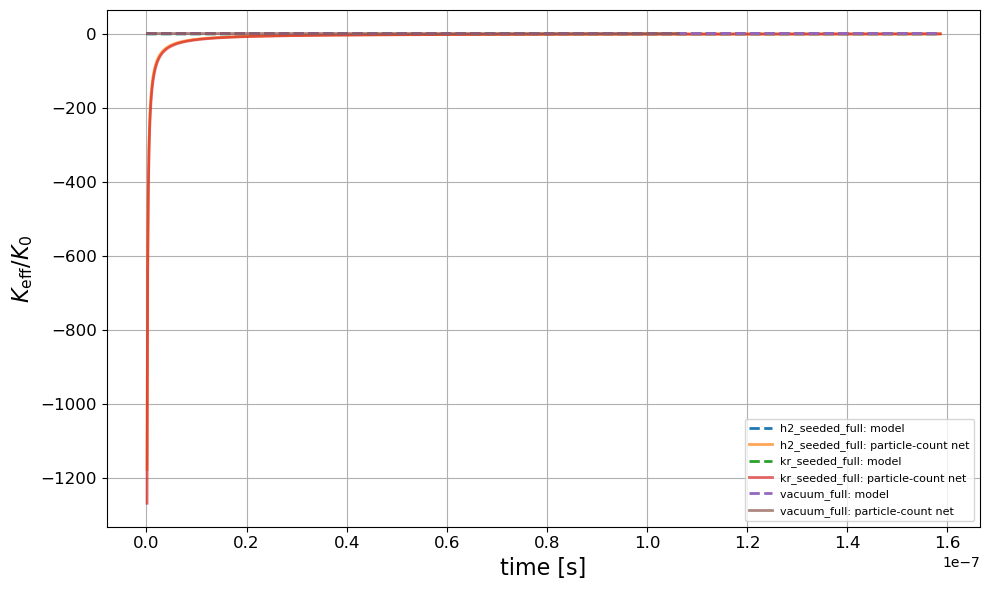

In [18]:
seeded_K = [(cd, h, m, meta) for cd, h, m, meta in perveance_cases if meta["method"] == "Seeded"]

if not seeded_K:
    print("No seeded cases found.")
else:
    plt.figure(figsize=(10, 6))
    for case_dir, hist, model, meta in seeded_K:
        if model is not None and "K_eff_model_over_K0" in model:
            plt.plot(model["t_est_s"], model["K_eff_model_over_K0"], "--", label=f"{meta['case']}: model", linewidth=2)
        if "K_eff_net_over_K0" in hist:
            plt.plot(hist["time_s"], hist["K_eff_net_over_K0"], alpha=0.7, label=f"{meta['case']}: particle-count net", linewidth=2)

    plt.xlabel("time [s]", fontsize=16)
    plt.ylabel(r"$K_{\rm eff}/K_0$", fontsize=16)
    #plt.title("Seeded-model effective perveance", fontsize=16)
    plt.grid(True)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=8)
    plt.tight_layout()
    path = PLOTS_DIR / "seeded_effective_perveance_over_K0.png"
    plt.savefig(path, dpi=200)
    print("Saved:", path)
    plt.show()


### 12.2 Dynamic-source perveance indicators

For C++ MCC and Python callback runs, the source creates both electrons and gas ions. Therefore two curves are useful:

- **Electron-only limit**: $K_{\rm eff,e}/K_0=1-N_e/N_p$.  
  This is the best-case perveance reduction if electrons remain confined and ions are cleared.

- **Net-charge estimate**: $K_{\rm eff,net}/K_0=1-(N_e-N_i)/N_p$.  
  This is the global charge-balance estimate inside the simulation domain. If ions remain with electrons, the net compensation can be small.

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_H2_2k_dynamic_perveance_indicators.png


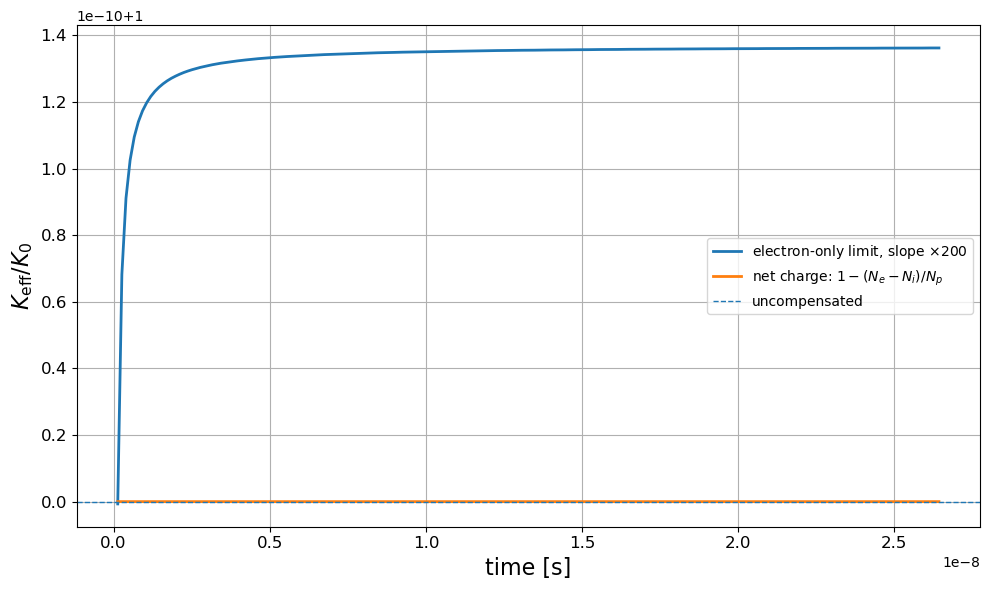

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_Kr_2k_dynamic_perveance_indicators.png


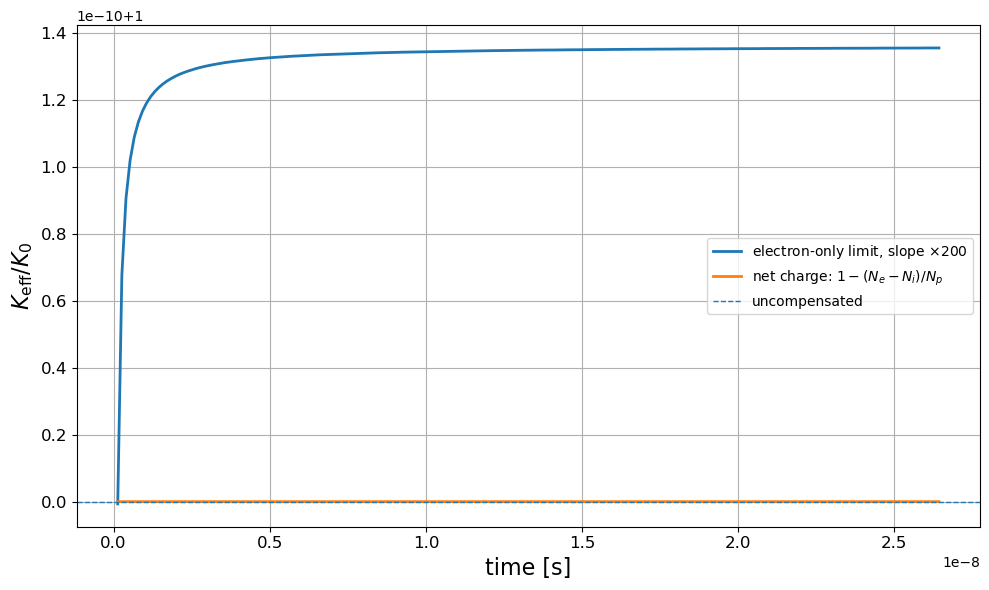

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/callback_vacuum_2k_dynamic_perveance_indicators.png


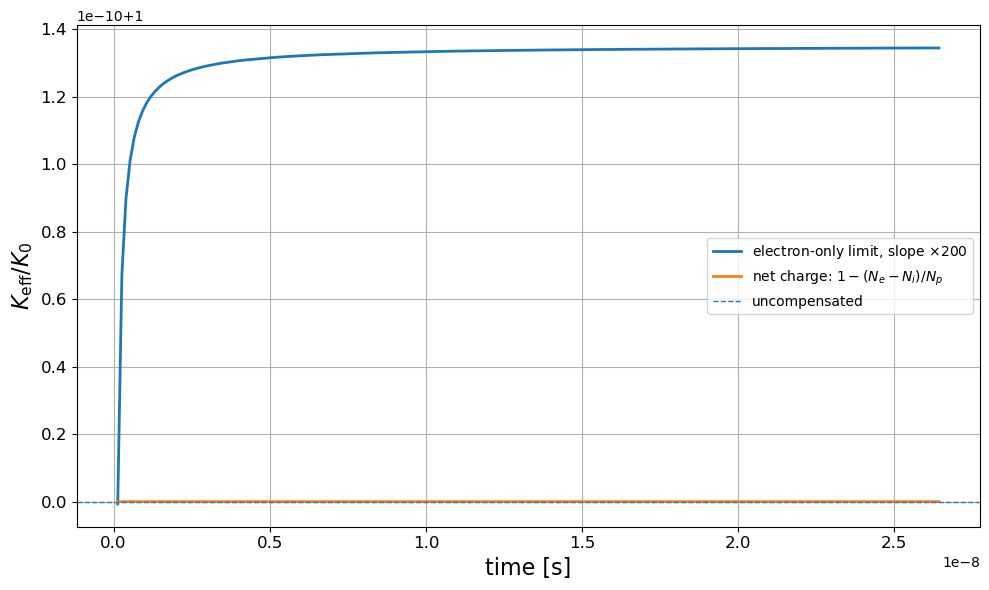

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/cxx_H2_mcc_20k_physical_dynamic_perveance_indicators.png


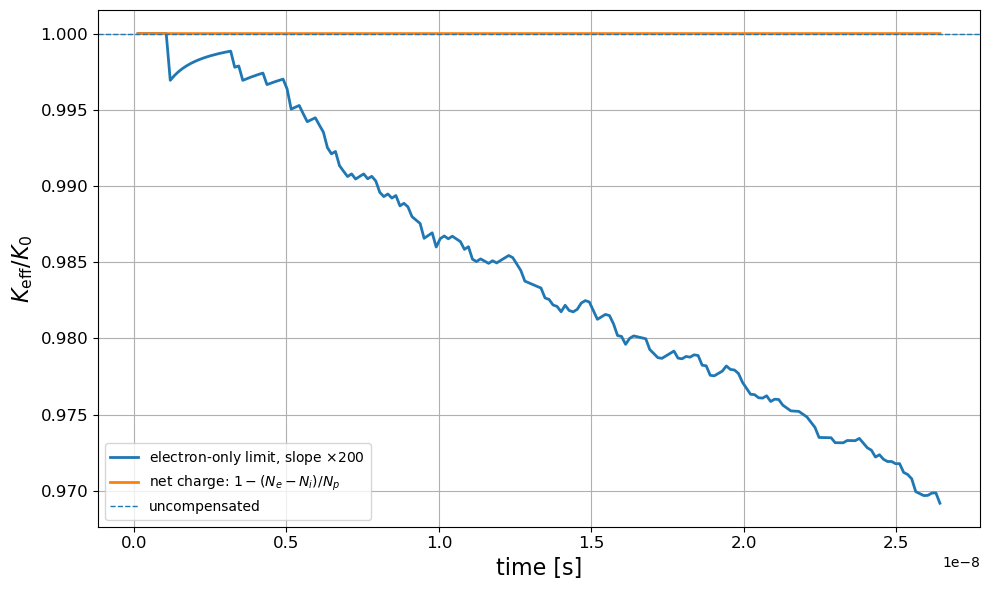

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/cxx_Kr_mcc_20k_physical_dynamic_perveance_indicators.png


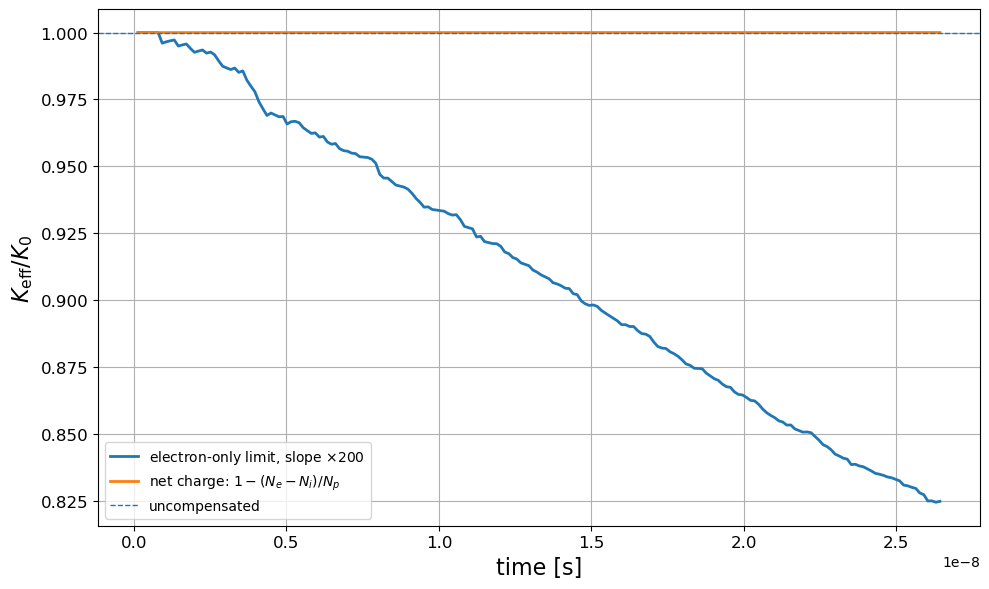

In [19]:
dynamic_K = [
    (cd, h, m, meta)
    for cd, h, m, meta in perveance_cases
    if meta["method"] in ["Python callback", "C++ MCC"]
]
slope_factor = 200.0   # change this value as needed

if not dynamic_K:
    print("No dynamic Python callback or C++ MCC cases found.")
else:
    for case_dir, hist, model, meta in dynamic_K:
        plt.figure(figsize=(10, 6))
        
#        plt.plot(
#            hist["time_s"],
#            hist["K_eff_electron_only_over_K0"],
#            label=r"electron-only limit: $1-N_e/N_p$", linewidth=2
#        )
#        plt.plot(
#            hist["time_s"],
#            hist["K_eff_net_over_K0"],
#            label=r"net charge: $1-(N_e-N_i)/N_p$", linewidth=2
#        )

        t = hist["time_s"].to_numpy()
        y_electron = hist["K_eff_electron_only_over_K0"].to_numpy()
        y_net = hist["K_eff_net_over_K0"].to_numpy()

        # Rescale electron-only curve slope while keeping the initial value fixed
        y0 = y_electron[1]
        y_electron_scaled = y0 + slope_factor * (y_electron - y0)

        plt.plot(
            t,
            y_electron_scaled,
            label=rf"electron-only limit, slope $\times {slope_factor:g}$",
            linewidth=2
        )

        plt.plot(
            t,
            y_net,
            label=r"net charge: $1-(N_e-N_i)/N_p$",
            linewidth=2
        )
        
        plt.axhline(1.0, linestyle="--", linewidth=1, label="uncompensated")
        plt.xlabel("time [s]", fontsize=16)
        plt.ylabel(r"$K_{\rm eff}/K_0$", fontsize=16)
        #plt.title(f"Dynamic-source perveance indicators: {meta['case']} ({meta['gas']})", fontsize=16)
        plt.grid(True)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.legend()
        #plt.ylim(ymax=1.01)#, ymin=0.9990)
        plt.tight_layout()
        path = PLOTS_DIR / f"{meta['case']}_dynamic_perveance_indicators.png"
        plt.savefig(path, dpi=200)
        print("Saved:", path)
        plt.show()

### 12.3 Final perveance comparison across cases

This bar plot compares the final relative perveance estimates for all available cases. For seeded cases, use the model-based value when available. For dynamic-source cases, show both the electron-only limit and the global net-charge estimate.

Saved: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/final_effective_perveance_comparison.png


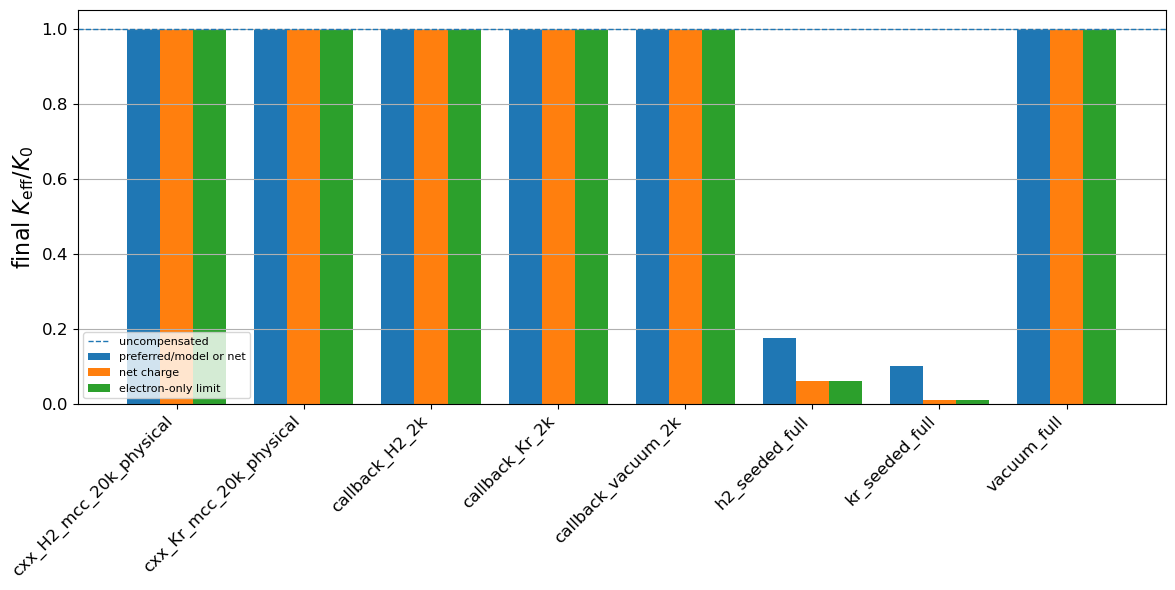

In [20]:
if len(perveance_summary):
    plot_df = perveance_summary.copy()

    preferred = []
    for _, row in plot_df.iterrows():
        if row["method"] == "Seeded" and np.isfinite(row["final_K_eff_model_over_K0"]):
            preferred.append(row["final_K_eff_model_over_K0"])
        else:
            preferred.append(row["final_K_eff_net_over_K0"])
    plot_df["preferred_K_eff_over_K0"] = preferred

    x = np.arange(len(plot_df))
    width = 0.26

    plt.figure(figsize=(12, 6))
    plt.bar(x - width, plot_df["preferred_K_eff_over_K0"], width=width, label="preferred/model or net")
    plt.bar(x, plot_df["final_K_eff_net_over_K0"], width=width, label="net charge")
    plt.bar(x + width, plot_df["final_K_eff_electron_only_over_K0"], width=width, label="electron-only limit")

    plt.axhline(1.0, linestyle="--", linewidth=1, label="uncompensated")
    plt.xticks(x, plot_df["case"], rotation=45, ha="right", fontsize=12)
    plt.ylabel(r"final $K_{\rm eff}/K_0$", fontsize=16)
    #plt.title("Final effective perveance comparison"), fontsize=16
    plt.grid(True, axis="y")
    plt.yticks(fontsize=12)
    plt.legend(fontsize=8)
    plt.tight_layout()
    path = PLOTS_DIR / "final_effective_perveance_comparison.png"
    plt.savefig(path, dpi=200)
    print("Saved:", path)
    plt.show()

### 12.4 Presentation-ready perveance summary

Use this table for slide preparation. Values below 1 indicate reduced effective space-charge perveance. Values above 1 indicate that positive ions dominate the global charge balance in that diagnostic.

In [21]:
if len(perveance_summary):
    slide_cols = [
        "case", "method", "gas",
        "final_model_neutralization",
        "final_global_net_neutralization",
        "final_electron_over_proton",
        "final_ion_over_proton",
        "final_K_eff_model_over_K0",
        "final_K_eff_net_over_K0",
        "final_K_eff_electron_only_over_K0",
    ]
    slide_table = perveance_summary[[c for c in slide_cols if c in perveance_summary.columns]].copy()
    display(slide_table)

    out = PLOTS_DIR / "presentation_perveance_summary.csv"
    slide_table.to_csv(out, index=False)
    print("Wrote:", out)

,case,method,gas,final_model_neutralization,final_global_net_neutralization,final_electron_over_proton,final_ion_over_proton,final_K_eff_model_over_K0,final_K_eff_net_over_K0,final_K_eff_electron_only_over_K0
0,cxx_H2_mcc_20k_physical,C++ MCC,H2,0.000000,-1.381472e-06,1.540341e-04,1.554156e-04,1.000000,1.000001,0.999846
1,cxx_Kr_mcc_20k_physical,C++ MCC,Kr,0.000000,-3.731761e-05,8.762728e-04,9.135904e-04,1.000000,1.000037,0.999124
2,callback_H2_2k,Python callback,H2,NaN,-1.368014e-17,3.427730e-15,3.441410e-15,0.999671,1.000000,1.000000
3,callback_Kr_2k,Python callback,Kr,NaN,-3.420675e-18,3.422386e-15,3.425806e-15,0.998173,1.000000,1.000000
4,callback_vacuum_2k,Python callback,vacuum,NaN,-3.249561e-17,3.397501e-15,3.429997e-15,0.999671,1.000000,1.000000
5,h2_seeded_full,Seeded,H2,0.825532,9.409045e-01,9.409045e-01,6.937766e-16,0.174468,0.059096,0.059096
6,kr_seeded_full,Seeded,Kr,0.899999,9.908603e-01,9.908603e-01,7.813702e-16,0.100001,0.009140,0.009140
7,vacuum_full,Seeded,vacuum,0.000000,-8.587393e-16,0.000000e+00,8.587393e-16,1.000000,1.000000,1.000000


Wrote: /home/cspark/Work/projects/plasma_column/simulations/analysis_plots/presentation_perveance_summary.csv
